[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/MFM/blob/main/notebooks/EN/chapter5_lecture_notebook.ipynb)

# Modelling Financial Markets — Chapter 5: Conditional Volatility, GARCH Models

*Lecture notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

This notebook reproduces the main charts and tables of Lecture 5 (the case study has its own Quantlet) on real daily data: S&P 500, BET, BET-TR, Bitcoin, EUR/RON (BNR) and gold, with the VIX as a benchmark.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/MFM/Chapter_5'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


In [1]:
# the arch package (Kevin Sheppard) is not preinstalled on Colab
try:
    import arch
except ImportError:
    import subprocess
    import sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'arch'], check=True)

In [2]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats, optimize
from scipy.signal import lfilter
from scipy.special import gammaln
from arch import arch_model
from arch.univariate import ARCHInMean, ConstantMean, GARCH, FIGARCH, StudentsT, ZeroMean
import warnings
warnings.filterwarnings('ignore')

## Chart style and output folder

In [3]:
# Chart style: transparent background, legend below the plot
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
# font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['xtick.labelsize'] = 11.5
plt.rcParams['ytick.labelsize'] = 11.5
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.linewidth'] = 0.6
plt.rcParams['lines.linewidth'] = 1.4
plt.rcParams['legend.facecolor'] = 'none'
plt.rcParams['legend.framealpha'] = 0
plt.rcParams['legend.fontsize'] = 11

# Chart colours
MainBlue = '#1A3A6E'
IDAred   = '#CD0000'
Forest   = '#2E7D32'
Amber    = '#B5853F'
Orange   = '#E67E22'
Purple   = '#8E44AD'
Gray     = '#7F7F7F'
LightGray = '#DADADA'
Teal     = '#17A2B8'
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'btc': Amber, 'eurron': Forest, 'gold': Purple}

SEED = 42
TABLE_DIR = '.'
NUM = {}


def save_fig(name):
    """Save the figure as transparent PDF and PNG in the current folder."""
    plt.savefig(f'{name}.pdf', bbox_inches='tight', transparent=True)
    plt.savefig(f'{name}.png', bbox_inches='tight', transparent=True, dpi=180)
    plt.show()
    plt.close()
    print(f"   saved {name}")


def legend_outside_bottom(ax, ncol=2, y=-0.22):
    """Place the legend outside the plot, bottom centre."""
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def acf(x, nlags):
    x = np.asarray(x) - np.mean(x)
    d = np.sum(x ** 2)
    return np.array([np.sum(x[k:] * x[:-k]) / d for k in range(1, nlags + 1)])


import tempfile
# outputs go to OUT_DIR (Google Drive) if SAVE_TO_DRIVE = True, otherwise to a temporary folder
OUT_PATH = OUT_DIR if globals().get('SAVE_TO_DRIVE') else tempfile.gettempdir()
TABLE_DIR = OUT_PATH


def save_fig(name):
    """Save the figure as PDF and PNG in OUT_PATH, then show it."""
    plt.savefig(os.path.join(OUT_PATH, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(OUT_PATH, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    plt.show()
    plt.close()

## Data

- Daily closes up to 18 September 2026; returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$.
- Equity indices and gold: weekdays only, days with an unchanged close (filled holidays) removed; gold is annualised with its actual frequency.
- Bitcoin trades 7 days a week; EUR/RON is the BNR official reference rate.
- Each series is analysed on its own calendar.

In [4]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'

# name -> (symbol, label, group, start date)
MARKETS = {
    'sp500':  ('GSPC.INDX',      'S&P 500',                 'Equity', '2000-01-01'),
    'bet':    ('BET',            'BET',                     'Equity', '2000-01-01'),
    'bettr':  ('BETTR.INDX',     'BET-TR',                  'Equity', '2014-09-23'),
    'btc':    ('BTC-USD.CC',     'Bitcoin',                 'Crypto', '2014-09-17'),
    'eurron': ('REF:EUR',        'EUR/RON (BNR reference)', 'FX',     '2005-07-01'),
    'gold':   ('XAUUSD.FOREX',   'Gold (XAU/USD)',          'Commodity', '2000-01-01'),
}
LABELS = {k: v[1] for k, v in MARKETS.items()}

_CACHE = {}


def read_market(symbol):
    """Daily price table of one symbol (local copy of the course data, or GitHub)."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname)
    src = path if os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official RON reference rate (annual BNR XML archives)."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(int(start[:4]), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}">([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END):
    """Daily closing price, cleaned with the chapter conventions."""
    symbol, _, group, start0 = MARKETS[name]
    start = start or start0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    s = read_market(symbol)['close'].loc[start:end]
    s = s[s > 0].dropna()
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    return s.rename(name)


def pct_returns(name, start=None, end=END):
    """Daily log returns in percent, on the series' own calendar."""
    return (100 * np.log(load_close(name, start, end)).diff().dropna()).rename(name)


def periods_per_year(r):
    """Average number of observations per calendar year (actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years


def load_vix(start='2000-01-01', end=END):
    """The VIX index (30-day implied volatility of the S&P 500, annualised percent)."""
    s = read_market('VIX.INDX')['close'].loc[start:end]
    return s[s.index.dayofweek < 5].rename('vix')


rets = {k: pct_returns(k) for k in MARKETS}
PPY = {k: periods_per_year(rets[k]) for k in MARKETS}
ORDER = list(MARKETS)
MAIN = ['sp500', 'bet', 'btc', 'eurron', 'gold']
for k in ORDER:
    print(f'{LABELS[k]:26s}', rets[k].index[0].date(), '->', rets[k].index[-1].date(), len(rets[k]), 'obs',
          round(PPY[k], 1), 'obs/year')

S&P 500                    2000-01-04 -> 2026-09-18 6714 obs 251.4 obs/year
BET                        2000-01-06 -> 2026-09-18 6670 obs 249.8 obs/year
BET-TR                     2014-09-24 -> 2026-09-18 2992 obs 249.7 obs/year
Bitcoin                    2014-09-18 -> 2026-09-18 4384 obs 365.3 obs/year
EUR/RON (BNR reference)    2005-07-05 -> 2026-09-18 5352 obs 252.4 obs/year
Gold (XAU/USD)             2000-01-04 -> 2026-09-18 6922 obs 259.2 obs/year


## GARCH tools

- `fit_garch`: GARCH, GJR-GARCH or EGARCH with Normal, Student-t, skewed-t or GED innovations (package `arch`); low-volatility series are rescaled internally and the parameters converted back.
- `half_life`, `news_impact`, `sign_bias_test`, `ljung_box`, `arch_lm`, `ewma_variance`, `qlike`, `mz_regression`, `dm_test`.

In [5]:
VOL_SPEC = {'GARCH': dict(vol='GARCH', p=1, o=0, q=1),
            'GJR': dict(vol='GARCH', p=1, o=1, q=1),
            'EGARCH': dict(vol='EGARCH', p=1, o=1, q=1)}
DISTS = {'normal': 'Normal', 't': 'Student-t', 'skewt': 'Skewed-t', 'ged': 'GED'}


class Fit:
    """Result of one fit, in the units of the original series (returns in %)."""

    def __init__(self, res, c, r, vol):
        self.res, self.c, self.r, self.vol = res, c, r, vol
        p = res.params.copy()
        p['mu'] = p['mu'] / c
        if vol == 'EGARCH':
            p['omega'] = p['omega'] - (1 - p['beta[1]']) * np.log(c ** 2)
        else:
            p['omega'] = p['omega'] / c ** 2
        self.params = p
        # robust (Bollerslev-Wooldridge) covariance mapped to the original units with the Jacobian
        # of the transformation: mu/c, omega/c^2 (GARCH, GJR) or omega - (1 - beta) ln c^2 (EGARCH)
        names = list(res.params.index)
        J = np.eye(len(names))
        J[names.index('mu'), names.index('mu')] = 1 / c
        if vol == 'EGARCH':
            J[names.index('omega'), names.index('beta[1]')] = np.log(c ** 2)
        else:
            J[names.index('omega'), names.index('omega')] = 1 / c ** 2
        self.cov = pd.DataFrame(J @ res.param_cov.values @ J.T, index=names, columns=names)
        self.se = pd.Series(np.sqrt(np.diag(self.cov.values)), index=names)
        self.tvalues = p[names] / self.se
        self.pvalues = pd.Series(2 * stats.norm.sf(np.abs(self.tvalues.values)), index=names)
        n = res.nobs
        self.nobs = n
        self.loglik = res.loglikelihood + n * np.log(c)
        k = len(p)
        self.aic = -2 * self.loglik + 2 * k
        self.bic = -2 * self.loglik + k * np.log(n)
        self.sigma = res.conditional_volatility / c
        self.z = res.std_resid
        self.eps = res.resid / c                   # unstandardised residuals, in the units of the original series
        self.converged = res.convergence_flag == 0

    @property
    def persistence(self):
        p = self.params
        if self.vol == 'EGARCH':
            return p['beta[1]']
        g = p.get('gamma[1]', 0.0)
        return p['alpha[1]'] + p['beta[1]'] + g * self.neg_share()

    def neg_share(self):
        """E[z^2 1(z < 0)] for the innovation distribution (0.5 if symmetric); enters the GJR persistence."""
        d = self.res.model.distribution
        if d.name.startswith('Standardized Skew'):
            from scipy import integrate
            par = self.res.params[d.parameter_names()].values
            pdf = lambda x: float(np.exp(d.loglikelihood(par, np.array([x]), np.array([1.0]), individual=True))[0])
            return float(integrate.quad(lambda x: x ** 2 * pdf(x), -np.inf, 0, limit=200)[0])
        return 0.5

    def uncond_var(self):
        p = self.params
        if self.vol == 'EGARCH':
            return np.nan
        return p['omega'] / (1 - self.persistence)

    def forecast_var(self, horizon):
        """Daily variance forecasts for t+1, ..., t+h, in %^2."""
        f = self.res.forecast(horizon=horizon, reindex=False, method='analytic' if self.vol != 'EGARCH' else 'simulation',
                              simulations=2000)
        return f.variance.iloc[-1].values / self.c ** 2


def scale_for(r):
    """Rescaling factor (a power of 10) that makes the standard deviation of order 1."""
    s = r.std()
    return 10.0 if s < 0.5 else 1.0


def fit_garch(r, vol='GARCH', dist='t', mean='Constant', last_obs=None, c=None):
    c = scale_for(r) if c is None else c
    am = arch_model(c * r, mean=mean, dist=dist, **VOL_SPEC[vol])
    res = am.fit(disp='off', last_obs=last_obs, options={'maxiter': 1000})
    return Fit(res, c, r, vol)


def half_life(persistence):
    """Number of days after which half of a variance shock has gone."""
    return np.log(0.5) / np.log(persistence) if 0 < persistence < 1 else np.inf


def news_impact(fit, eps, sigma2_bar=None):
    """sigma^2_t as a function of the shock eps_{t-1}, with sigma^2_{t-1} fixed at the sample variance."""
    p = fit.params
    s2 = fit.r.var() if sigma2_bar is None else sigma2_bar
    if fit.vol == 'EGARCH':
        z = eps / np.sqrt(s2)
        return np.exp(p['omega'] + p['alpha[1]'] * (np.abs(z) - np.sqrt(2 / np.pi)) + p['gamma[1]'] * z
                      + p['beta[1]'] * np.log(s2))
    g = p.get('gamma[1]', 0.0)
    return p['omega'] + (p['alpha[1]'] + g * (eps < 0)) * eps ** 2 + p['beta[1]'] * s2


def sign_bias_test(z, eps):
    """Engle-Ng (1993, eq. 18): z_t^2 on S-_{t-1}, S-_{t-1} eps_{t-1}, S+_{t-1} eps_{t-1}, with eps_{t-1} the
    UNSTANDARDISED residual and z_t the standardised residual; t statistics and the joint test T R^2 ~ chi2(3)."""
    d = pd.concat([pd.Series(z), pd.Series(eps)], axis=1, keys=['z', 'e']).dropna()
    z, e = d['z'].values, d['e'].values
    y = z[1:] ** 2
    el = e[:-1]
    sneg = (el < 0).astype(float)
    X = np.column_stack([np.ones_like(el), sneg, sneg * el, (1 - sneg) * el])
    ols = sm.OLS(y, X).fit()
    joint = len(y) * ols.rsquared
    return {'sign_t': ols.tvalues[1], 'neg_size_t': ols.tvalues[2], 'pos_size_t': ols.tvalues[3],
            'joint': joint, 'joint_p': 1 - stats.chi2.cdf(joint, 3)}


def ljung_box(x, lags=10):
    from statsmodels.stats.diagnostic import acorr_ljungbox
    lb = acorr_ljungbox(pd.Series(np.asarray(x)).dropna(), lags=[lags])
    return float(lb['lb_stat'].iloc[0]), float(lb['lb_pvalue'].iloc[0])


def arch_lm(x, lags=5):
    from statsmodels.stats.diagnostic import het_arch
    lm, lmp, _, _ = het_arch(pd.Series(np.asarray(x)).dropna(), nlags=lags)
    return float(lm), float(lmp)


def ewma_variance(r, lam=0.94, init=250):
    """EWMA forecast for day t+1 (aligned at t+1): s2_{t+1} = lam s2_t + (1 - lam) r_t^2."""
    x = r.values
    s2 = np.empty(len(x) + 1)
    s2[0] = np.mean(x[:init] ** 2)
    for t in range(len(x)):
        s2[t + 1] = lam * s2[t] + (1 - lam) * x[t] ** 2
    return pd.Series(s2[1:-1], index=r.index[1:])


def qlike(proxy, h):
    """QLIKE loss (Patton, 2011), the form used for comparisons: proxy/h + ln h."""
    return proxy / h + np.log(h)


def mz_regression(proxy, h, lags=5):
    """Mincer-Zarnowitz: proxy = a + b h + u, HAC errors; Wald test of a = 0, b = 1."""
    X = sm.add_constant(np.asarray(h))
    ols = sm.OLS(np.asarray(proxy), X).fit(cov_type='HAC', cov_kwds={'maxlags': lags})
    w = ols.wald_test((np.eye(2), np.array([0.0, 1.0])), scalar=True)
    return {'a': ols.params[0], 'b': ols.params[1], 'a_se': ols.bse[0], 'b_se': ols.bse[1],
            'r2': ols.rsquared, 'wald': float(w.statistic), 'wald_p': float(w.pvalue)}


def dm_test(loss_a, loss_b, lags=5):
    """Diebold-Mariano: d = L_a - L_b; HAC t statistic for the mean of d (negative: A better)."""
    d = np.asarray(loss_a) - np.asarray(loss_b)
    ols = sm.OLS(d, np.ones_like(d)).fit(cov_type='HAC', cov_kwds={'maxlags': lags})
    t = float(ols.tvalues[0])
    return {'mean_diff': float(d.mean()), 't': t, 'p': 2 * (1 - stats.norm.cdf(abs(t)))}


LBL = {'T': 'Forecast origin', 'rT': 'Return on the last day r_T (%)', 'eps': 'Shock eps_T = r_T - mu', 's2T': 'Variance sigma_T^2', 's2n': "Tomorrow's variance sigma_{T+1}^2", 'uv': 'Long-run variance', 'h10': 'Variance forecast for day T+10', 'sum10': '10-day variance (sum of the forecasts)', 'vol10_pct': '10-day volatility (%)', 'cond': 'Fourth-moment condition (alpha+beta)^2 + 2 alpha^2', 'K': 'Kurtosis K', 'corr': 'Correlation of GARCH-t volatility and the VIX', 'mean_vix': 'Mean VIX (%)', 'mean_garch': 'Mean GARCH-t volatility (%)', 'max_garch': 'Highest GARCH-t volatility (%)', 'max_garch_date': 'Date of the highest GARCH-t volatility', 'min_garch': 'Lowest GARCH-t volatility (%)', 'min_garch_date': 'Date of the lowest GARCH-t volatility', 'share_vix_above': 'Share of days with the VIX above GARCH-t', 'garch_max': 'Peak GARCH-t volatility, 2020 (%)', 'gjr_max': 'Peak GJR-t volatility, 2020 (%)', 'vix_max': 'Peak VIX, 2020', 'vix_max_date': 'Date of the VIX peak', 'garch_max_date': 'Date of the GARCH-t peak', 'rmin': 'Lowest return, 2020 (%)', 'rmin_date': 'Date of the lowest return', 'vix_0221': 'VIX on 21 Feb 2020', 'vix_0224': 'VIX on 24 Feb 2020', 'garch_0224': 'GARCH-t volatility on 24 Feb 2020 (%)', 'garch_0225': 'GARCH-t volatility on 25 Feb 2020 (%)', 'r_0224': 'Return on 24 Feb 2020 (%)', 'z_kurt': 'Excess kurtosis of z', 'z_skew': 'Skewness of z', 'jb': 'Jarque-Bera statistic', 'z_min': 'Smallest z', 'z_min_date': 'Date of the smallest z', 'nu_t': 'Student-t degrees of freedom nu (GARCH-t)', 'r_kurt': 'Excess kurtosis of the returns', 'n_below4': 'Residuals below -4', 'exp_below4_normal': 'Expected below -4, Normal', 'exp_below4_t': 'Expected below -4, Student-t', 'skewt_eta': 'Skewed-t degrees of freedom nu (GJR)', 'skewt_lambda': 'Skewed-t asymmetry lambda (GJR)', 'r_1': 'ACF of r_t, lag 1', 'r2_1': 'ACF of r_t^2, lag 1', 'r2_10': 'ACF of r_t^2, lag 10', 'r2_50': 'ACF of r_t^2, lag 50', 'band': '95% band', 'n_r2_sig': 'Significant lags of r_t^2', 'n_r_sig': 'Significant lags of r_t', 'kurt_garch': 'Excess kurtosis, simulated GARCH', 'acf1_x2': 'ACF of squared returns, lag 1', 'kurt_theory': 'Theoretical excess kurtosis', 'uvar': 'Unconditional variance', 's2bar': 'Long-run variance', 'gjr_m3': 'GJR variance after a -3% shock', 'gjr_p3': 'GJR variance after a +3% shock', 'eg_m3': 'EGARCH variance after a -3% shock', 'eg_p3': 'EGARCH variance after a +3% shock', 'g_pm3': 'GARCH variance after a shock of +/-3%', 'emp_1': 'ACF of |r_t|, lag 1, data', 'emp_100': 'ACF of |r_t|, lag 100, data', 'emp_250': 'ACF of |r_t|, lag 250, data', 'garch_1': 'ACF of |r_t|, lag 1, GARCH', 'garch_100': 'ACF of |r_t|, lag 100, GARCH', 'garch_250': 'ACF of |r_t|, lag 250, GARCH', 'fig_1': 'ACF of |r_t|, lag 1, FIGARCH', 'fig_100': 'ACF of |r_t|, lag 100, FIGARCH', 'fig_250': 'ACF of |r_t|, lag 250, FIGARCH', 'd': 'FIGARCH memory parameter d', 'd_se': 's.e. of d', 'fig_bic': 'BIC, FIGARCH', 'garch_bic': 'BIC, GARCH', 'kappa_z': 'Kurtosis of z', 'theory_ratio': 'Theoretical s.e. ratio sqrt((kappa_z - 1)/2)', 'ratio_alpha': 'Observed robust/classical ratio, alpha', 'ratio_beta': 'Observed robust/classical ratio, beta', 'kappa_half': 'Kurtosis of z, first half of the sample', 'alpha': 'alpha', 'beta': 'beta', 'gamma': 'gamma', 'lr': 'LR statistic', 'p_mix': 'p-value, mixture 1/2 chi2(0) + 1/2 chi2(1)', 'nu': 'nu', 'crit_mix': '5% critical value, mixture', 'crit_chi2': '5% critical value, chi2(1)', 'gjr_alpha': 'alpha of GJR-t, S&P 500', 'pers': 'Persistence p = alpha + beta', 'se_p': 's.e. of p', 's2': 'Long-run variance', 'se_s2': 's.e. of the long-run variance', 'vol': 'Long-run volatility (% p.a.)', 'se_vol': 's.e. of the long-run volatility', 'hl': 'Half-life (days)', 'dh': 'dh/dp', 'se_hl': 's.e. of the half-life (delta method)', 'p_lo': '95% interval for p, lower end', 'p_hi': '95% interval for p, upper end', 'hl_lo': 'Half-life at the lower end of p', 'rho1': 'rho_1(eps^2), model', 'rho10': 'rho_10(eps^2), model', 'rho1_sample': 'rho_1(eps^2), sample', 'rho10_sample': 'rho_10(eps^2), sample', 'cond3': 'Condition, estimates rounded to 3 decimals', 'K3': 'Kurtosis K, estimates rounded to 3 decimals', 'rho13': 'rho_1, rounded estimates', 'M': 'Number of lags M', 'q_lb': 'Ljung-Box Q on z^2 (naive)', 'p_lb': 'p-value, naive', 'q_lm': 'Li-Mak corrected statistic', 'p_lm': 'p-value, Li-Mak', 'r1': 'First autocorrelation of z^2', 'c11': 'C[1,1]', 'c55': 'C[5,5]', 'cMM': 'C[M,M]', 'trace_loss': 'M - trace(C)', 'eta': 'Skewed-t degrees of freedom nu', 'lam': 'Skewed-t asymmetry lambda', 'm_neg': 'E[z^2 1(z<0)]', 'p_neg': 'P(z<0)', 'pers_sym': 'Persistence with 1/2', 'pers_skew': 'Persistence with E[z^2 1(z<0)]', 'll_garch': 'Log-likelihood, GARCH', 'll_gjr': 'Log-likelihood, GJR', 'aic_garch': 'AIC, GARCH', 'aic_gjr': 'AIC, GJR', 'bic_garch': 'BIC, GARCH', 'bic_gjr': 'BIC, GJR', 'lr_p': 'LR p-value, chi2(1)', 'gamma_t': 'Robust t of gamma', 'B': 'Bootstrap paths B', 'est': 'Estimated persistence p', 'pers_lo': '2.5% percentile of p*', 'pers_hi': '97.5% percentile of p*', 'pers_sd': 'Standard deviation of p*', 'pers_mean': 'Mean of p*', 'hl_med': 'Median half-life (days)', 'hl_hi': '97.5% percentile of the half-life', 'share_inf': 'Share of draws with an infinite half-life', 'share_ge_0999': 'Share of draws with p* >= 0.999', 'se_robust_sum': 'Robust s.e. of alpha + beta', 'alpha0': 'alpha under H0 (IGARCH-t)', 'omega0': 'omega under H0', 'nu0': 'nu under H0', 'p_chi2': 'p-value, naive chi2(1)', 'p_boot_pers': 'Bootstrap p-value of alpha + beta', 'p_boot_lr': 'Bootstrap p-value of LR', 'share_bound': 'Share of re-estimates with alpha + beta >= 0.999', 'lr_q95': '95% quantile of LR*', 'pers_q05': '5% quantile of p* under H0'}


def show(title, d, skip=()):
    """Print a dictionary of results as labelled lines."""
    print(title)
    for k, v in d.items():
        if k in skip or isinstance(v, (dict, list)):
            continue
        s = f'{v:.4f}' if isinstance(v, float) else str(v)
        print(f'  {LBL.get(k, k)}: {s}')


## 1. Volatility clustering and ARCH effects

- Ljung–Box $Q(10)$ on $r_t^2$ and Engle's LM(5) test on demeaned returns.

market         sp500         bet       bettr         btc  \
label        S&P 500         BET      BET-TR     Bitcoin   
start     2000-01-04  2000-01-06  2014-09-24  2014-09-18   
N               6714        6670        2992        4384   
ppy          251.414     249.817     249.675     365.333   
ann_vol       19.234      22.106      15.448      66.615   
kurt          10.666      11.063       17.79      11.958   
skew          -0.348      -0.653        -1.4      -0.705   
Q10_r         96.263     108.018      69.976      20.178   
Q10_r_p          0.0         0.0         0.0       0.028   
Q10_r2      6132.817    2439.975     713.548     212.745   
Q10_r2_p         0.0         0.0         0.0         0.0   
LM5          1683.86     981.515     370.835     114.666   
LM5_p            0.0         0.0         0.0         0.0   
acf1_r2        0.313        0.33       0.171       0.137   
acf1_r        -0.099       0.109       0.061      -0.022   

market                     eurron      

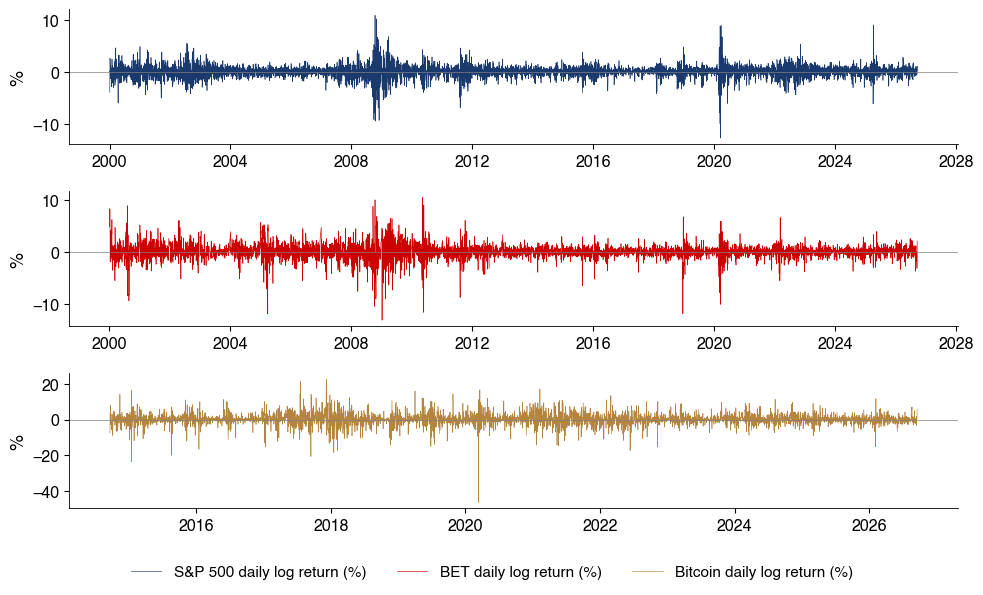

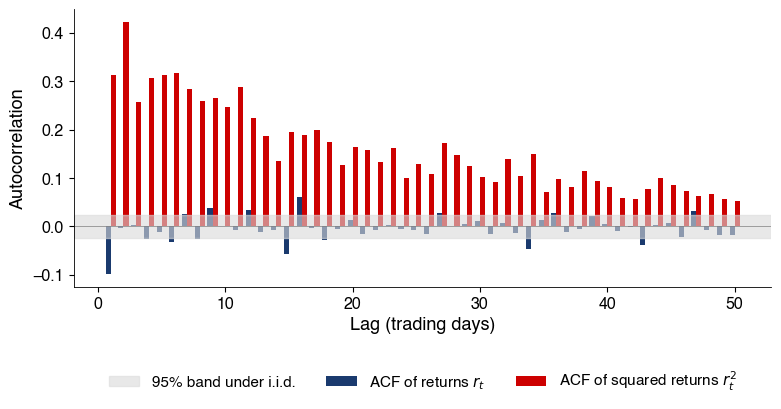

S&P 500 autocorrelations
  ACF of r_t, lag 1: -0.0986
  ACF of r_t^2, lag 1: 0.3132
  ACF of r_t^2, lag 10: 0.2474
  ACF of r_t^2, lag 50: 0.0528
  95% band: 0.0239
  Significant lags of r_t^2: 50
  Significant lags of r_t: 15


In [6]:
def arch_effects_table():
    rows = []
    for k in ORDER:
        r = rets[k]
        q, qp = ljung_box(r ** 2, 10)
        q1, q1p = ljung_box(r, 10)
        lm, lmp = arch_lm(r - r.mean(), 5)
        rows.append(dict(market=k, label=LABELS[k], start=str(r.index[0].date()), N=len(r), ppy=PPY[k],
                         ann_vol=r.std() * np.sqrt(PPY[k]), kurt=stats.kurtosis(r), skew=stats.skew(r),
                         Q10_r=q1, Q10_r_p=q1p, Q10_r2=q, Q10_r2_p=qp, LM5=lm, LM5_p=lmp,
                         acf1_r2=acf(r ** 2, 1)[0], acf1_r=acf(r, 1)[0]))
    t = pd.DataFrame(rows).set_index('market')
    t.to_csv(os.path.join(TABLE_DIR, 'ch5_arch_effects.csv'))
    return t


def fig_clustering():
    fig, axes = plt.subplots(3, 1, figsize=(10, 5.6), sharex=False)
    for ax, k in zip(axes, ['sp500', 'bet', 'btc']):
        r = rets[k]
        ax.plot(r.index, r.values, color=COL[k], lw=0.45, label=f'{LABELS[k]} daily log return (%)')
        ax.set_ylabel('%')
        ax.axhline(0, color=Gray, lw=0.5)
    fig.tight_layout()
    h = [l for ax in axes for l in ax.get_lines() if not l.get_label().startswith('_')]
    fig.legend(h, [l.get_label() for l in h], loc='upper center', bbox_to_anchor=(0.5, 0.0), ncol=3, frameon=False)
    save_fig('ch5_clustering')


def fig_acf_r_r2():
    r = rets['sp500']
    L = 50
    a1, a2 = acf(r, L), acf(r ** 2, L)
    fig, ax = plt.subplots(figsize=(9, 3.6))
    lags = np.arange(1, L + 1)
    ax.bar(lags - 0.2, a1, width=0.4, color=MainBlue, label='ACF of returns $r_t$')
    ax.bar(lags + 0.2, a2, width=0.4, color=IDAred, label='ACF of squared returns $r_t^2$')
    b = 1.96 / np.sqrt(len(r))
    ax.axhspan(-b, b, color=LightGray, alpha=0.6, label='95% band under i.i.d.')
    ax.axhline(0, color=Gray, lw=0.5)
    ax.set_xlabel('Lag (trading days)')
    ax.set_ylabel('Autocorrelation')
    legend_outside_bottom(ax, ncol=3, y=-0.25)
    save_fig('ch5_acf_r_r2')
    NUM['acf_sp500'] = {'r_1': a1[0], 'r2_1': a2[0], 'r2_10': a2[9], 'r2_50': a2[49], 'band': b,
                        'n_r2_sig': int((np.abs(a2) > b).sum()), 'n_r_sig': int((np.abs(a1) > b).sum())}


ae = arch_effects_table()
print(ae.round(3).T)
fig_clustering()
fig_acf_r_r2()
show('S&P 500 autocorrelations', NUM['acf_sp500'])

## 2. Simulation: GARCH produces clustering

- GARCH(1,1) with $\omega = 0.02$, $\alpha = 0.10$, $\beta = 0.88$ next to i.i.d. Normal returns.

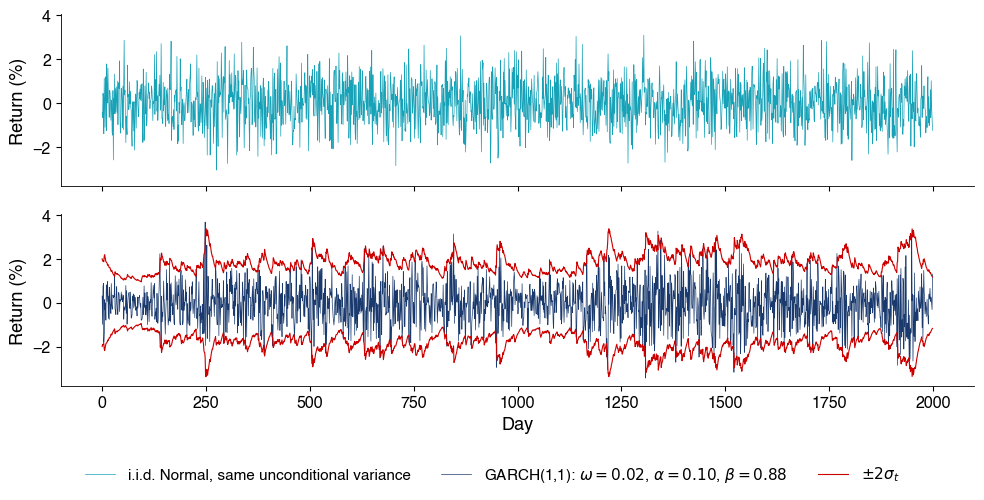

Simulated GARCH(1,1)
  Excess kurtosis, simulated GARCH: 2.4695
  ACF of squared returns, lag 1: 0.2605
  Theoretical excess kurtosis: 3.0612
  Unconditional variance: 1.0000


In [7]:
def fig_simulation():
    n = 2000
    rng = np.random.default_rng(SEED)
    om, al, be = 0.02, 0.10, 0.88
    s2 = np.empty(n)
    x = np.empty(n)
    s2[0] = om / (1 - al - be)
    z = rng.standard_normal(n)
    for t in range(n):
        if t > 0:
            s2[t] = om + al * x[t - 1] ** 2 + be * s2[t - 1]
        x[t] = np.sqrt(s2[t]) * z[t]
    iid = np.sqrt(om / (1 - al - be)) * rng.standard_normal(n)
    fig, axes = plt.subplots(2, 1, figsize=(10, 4.6), sharex=True, sharey=True)
    axes[0].plot(iid, color=Teal, lw=0.5, label='i.i.d. Normal, same unconditional variance')
    axes[1].plot(x, color=MainBlue, lw=0.5, label=r'GARCH(1,1): $\omega=0.02$, $\alpha=0.10$, $\beta=0.88$')
    axes[1].plot(2 * np.sqrt(s2), color=IDAred, lw=0.8, label=r'$\pm 2\sigma_t$')
    axes[1].plot(-2 * np.sqrt(s2), color=IDAred, lw=0.8)
    for ax in axes:
        ax.set_ylabel('Return (%)')
    axes[1].set_xlabel('Day')
    fig.tight_layout()
    h = [l for ax in axes for l in ax.get_lines() if not l.get_label().startswith('_')]
    fig.legend(h, [l.get_label() for l in h], loc='upper center', bbox_to_anchor=(0.5, 0.0), ncol=3, frameon=False)
    save_fig('ch5_simulation')
    # statistics on a long path (one million days), not on the 2000 days of the chart
    N = 1_000_000
    zl = rng.standard_normal(N)
    xl = np.empty(N)
    s = om / (1 - al - be)
    for t in range(N):
        xl[t] = np.sqrt(s) * zl[t]
        s = om + al * xl[t] ** 2 + be * s
    NUM['sim'] = {'kurt_garch': float(stats.kurtosis(xl)), 'acf1_x2': float(acf(xl ** 2, 1)[0]),
                  'kurt_theory': float(3 * (1 - (al + be) ** 2) / (1 - (al + be) ** 2 - 2 * al ** 2) - 3),
                  'uvar': om / (1 - al - be)}


fig_simulation()
show('Simulated GARCH(1,1)', NUM['sim'])

## 3. Estimation: 3 variance equations × 4 innovation distributions × 6 series

- Robust (Bollerslev–Wooldridge) standard errors are the default in `arch`.
- $\Delta$BIC: BIC minus the lowest BIC of the series.

In [8]:
def model_grid():
    rows, fits = [], {}
    for k in ORDER:
        r = rets[k]
        for vol in VOL_SPEC:
            for dist in DISTS:
                f = fit_garch(r, vol, dist)
                fits[(k, vol, dist)] = f
                p = f.params
                rows.append(dict(market=k, vol=vol, dist=dist, loglik=f.loglik, aic=f.aic, bic=f.bic,
                                 k=len(p), converged=f.converged, persistence=f.persistence,
                                 **{f'p_{n}': v for n, v in p.items()}))
    g = pd.DataFrame(rows)
    g['dbic'] = g['bic'] - g.groupby('market')['bic'].transform('min')
    g.to_csv(os.path.join(TABLE_DIR, 'ch5_model_grid.csv'), index=False)
    return g, fits


def garch_table(fits):
    """GARCH(1,1)-t on each series: parameters, robust and classical errors, persistence, half-life."""
    rows = []
    for k in ORDER:
        f = fits[(k, 'GARCH', 't')]
        p, se = f.params, f.se
        classic = f.res.model.fit(disp='off', cov_type='classic', starting_values=f.res.params.values).std_err
        pers = p['alpha[1]'] + p['beta[1]']
        uv = f.uncond_var()
        rows.append(dict(market=k, mu=p['mu'], omega=p['omega'], alpha=p['alpha[1]'], beta=p['beta[1]'], nu=p['nu'],
                         se_alpha=se['alpha[1]'], se_beta=se['beta[1]'], se_nu=se['nu'],
                         se_alpha_classic=classic['alpha[1]'], se_beta_classic=classic['beta[1]'],
                         persistence=pers, half_life=half_life(pers),
                         uncond_ann_vol=np.sqrt(uv * PPY[k]) if pers < 0.999 else np.nan,
                         last_ann_vol=f.sigma.iloc[-1] * np.sqrt(PPY[k]), loglik=f.loglik, N=f.nobs, scale=f.c))
    t = pd.DataFrame(rows).set_index('market')
    t.to_csv(os.path.join(TABLE_DIR, 'ch5_garch_table.csv'))
    return t


grid, FITS = model_grid()
gt = garch_table(FITS)
print(gt.round(4).T)
grid[grid.market == 'sp500'].pivot(index='vol', columns='dist', values='dbic').round(1)

market                sp500        bet      bettr           btc     eurron  \
mu                   0.0788     0.0832     0.1044  1.111000e-01     0.0007   
omega                0.0157     0.0448     0.0755  1.937000e-01     0.0000   
alpha                0.1226     0.1916     0.2062  1.087000e-01     0.1231   
beta                 0.8721     0.7991     0.7126  8.913000e-01     0.8769   
nu                   6.2562     5.0112     5.0219  3.180600e+00     4.1962   
se_alpha             0.0107     0.0246     0.0311  1.400000e-02     0.0110   
se_beta              0.0103     0.0237     0.0379  1.780000e-02     0.0120   
se_nu                0.4847     0.3084     0.4916  1.228000e-01     0.1853   
se_alpha_classic     0.0101     0.0184     0.0288  1.270000e-02     0.0086   
se_beta_classic      0.0096     0.0168     0.0342  1.300000e-02     0.0080   
persistence          0.9947     0.9907     0.9188  1.000000e+00     1.0000   
half_life          130.7335    74.2777     8.1822  2.044709e+11 

dist,ged,normal,skewt,t
vol,,,,
EGARCH,111.4,372.9,0.0,74.8
GARCH,339.8,648.9,307.4,346.7
GJR,141.6,394.7,49.6,119.9


## 4. Worked example: tomorrow's variance and the 10-day forecast

- $\sigma_{T+1}^2 = \omega + \alpha\varepsilon_T^2 + \beta\sigma_T^2$; $\E_T\sigma_{T+h}^2 = \sigma^2 + (\alpha+\beta)^{h-1}(\sigma_{T+1}^2 - \sigma^2)$.

In [9]:
def worked_example(fits):
    f = fits[('sp500', 'GARCH', 't')]
    p = f.params
    r = rets['sp500']
    T = r.index[-1]
    eps = r.iloc[-1] - p['mu']
    s2T = f.sigma.iloc[-1] ** 2
    s2n = p['omega'] + p['alpha[1]'] * eps ** 2 + p['beta[1]'] * s2T
    pers = p['alpha[1]'] + p['beta[1]']
    uv = p['omega'] / (1 - pers)
    h10 = uv + pers ** 9 * (s2n - uv)
    fc = f.forecast_var(10)
    NUM['worked'] = {'T': str(T.date()), 'rT': float(r.iloc[-1]), 'eps': float(eps), 's2T': float(s2T),
                     's2n': float(s2n), 'uv': float(uv), 'h10': float(h10), 'h10_arch': float(fc[-1]),
                     'h1_arch': float(fc[0]), 'sum10': float(fc.sum()), 'vol10_pct': float(np.sqrt(fc.sum()))}
    fn = fits[('sp500', 'GARCH', 'normal')]
    a, b = fn.params['alpha[1]'], fn.params['beta[1]']
    den = 1 - (a + b) ** 2 - 2 * a ** 2
    NUM['kurt_normal'] = {'alpha': float(a), 'beta': float(b), 'cond': float((a + b) ** 2 + 2 * a ** 2),
                          'K': float(3 * (1 - (a + b) ** 2) / den) if den > 0 else float('inf')}


worked_example(FITS)
show('Worked example, S&P 500, GARCH(1,1)-t', NUM['worked'], skip=('h10_arch', 'h1_arch'))
show('GARCH-N: fourth moment', NUM['kurt_normal'])

Worked example, S&P 500, GARCH(1,1)-t
  Forecast origin: 2026-09-18
  Return on the last day r_T (%): 0.1667
  Shock eps_T = r_T - mu: 0.0878
  Variance sigma_T^2: 0.5651
  Tomorrow's variance sigma_{T+1}^2: 0.5095
  Long-run variance: 2.9717
  Variance forecast for day T+10: 0.6242
  10-day variance (sum of the forecasts): 5.6726
  10-day volatility (%): 2.3817
GARCH-N: fourth moment
  alpha: 0.1206
  beta: 0.8599
  Fourth-moment condition (alpha+beta)^2 + 2 alpha^2: 0.9904
  Kurtosis K: 12.1239


## 5. Persistence, half-life and the volatility term structure

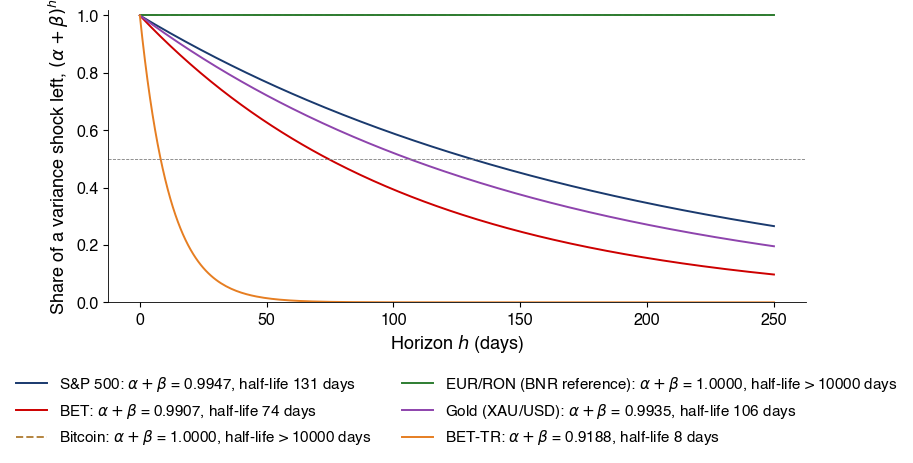

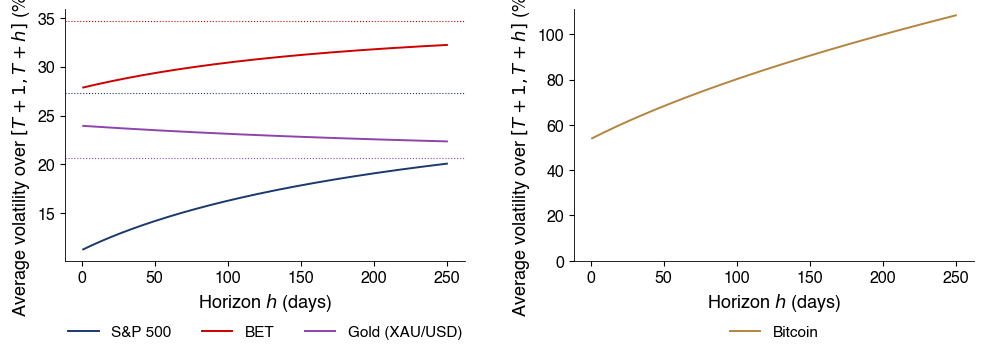

Average volatility over the next h days (% p.a.)


,h = 1,h = 22,h = 250,long run
sp500,11.3,12.7,20.1,27.3
bet,27.9,28.6,32.2,34.7
btc,54.1,60.6,108.3,NaN
eurron,1.0,1.0,1.1,NaN
gold,23.9,23.7,22.4,20.7


In [10]:
def fig_persistence(gt):
    H = 250
    h = np.arange(0, H + 1)
    fig, ax = plt.subplots(figsize=(9, 3.8))
    for k in MAIN + ['bettr']:
        pers = gt.loc[k, 'persistence']
        hl = gt.loc[k, 'half_life']
        lab = f'{LABELS[k]}: $\\alpha+\\beta$ = {pers:.4f}, half-life ' + (f'{hl:.0f} days' if np.isfinite(hl) and hl < 1e4 else '> 10000 days')
        ax.plot(h, pers ** h, color=COL[k], label=lab, ls='--' if k == 'btc' else '-')
    ax.axhline(0.5, color=Gray, lw=0.6, ls='--')
    ax.set_xlabel('Horizon $h$ (days)')
    ax.set_ylabel(r'Share of a variance shock left, $(\alpha+\beta)^h$')
    ax.set_ylim(0, 1.02)
    legend_outside_bottom(ax, ncol=2, y=-0.2)
    save_fig('ch5_persistence')


def fig_term_structure(fits, gt):
    H = 250
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
    ts = {}
    for k in MAIN:
        f = fits[(k, 'GARCH', 't')]
        v = f.forecast_var(H)
        avg = np.sqrt(np.cumsum(v) / np.arange(1, H + 1) * PPY[k])
        ts[k] = {'h1': float(np.sqrt(v[0] * PPY[k])), 'h22': float(avg[21]), 'h250': float(avg[-1]),
                 'uncond': float(gt.loc[k, 'uncond_ann_vol'])}
        if k == 'eurron':
            continue
        ax = axes[1] if k == 'btc' else axes[0]
        ax.plot(np.arange(1, H + 1), avg, color=COL[k], label=LABELS[k])
        if np.isfinite(gt.loc[k, 'uncond_ann_vol']):
            ax.axhline(gt.loc[k, 'uncond_ann_vol'], color=COL[k], ls=':', lw=0.8)
    for ax in axes:
        ax.set_xlabel('Horizon $h$ (days)')
        ax.set_ylabel('Average volatility over $[T+1, T+h]$ (% p.a.)')
        legend_outside_bottom(ax, ncol=3, y=-0.2)
    axes[1].set_ylim(0, None)
    fig.tight_layout()
    save_fig('ch5_term_structure')
    NUM['term'] = ts


fig_persistence(gt)
fig_term_structure(FITS, gt)
print('Average volatility over the next h days (% p.a.)')
pd.DataFrame(NUM['term']).T.rename(columns={'h1': 'h = 1', 'h22': 'h = 22', 'h250': 'h = 250', 'uncond': 'long run'}).round(1)

## 6. S&P 500: GARCH volatility, the VIX and the COVID-19 crash

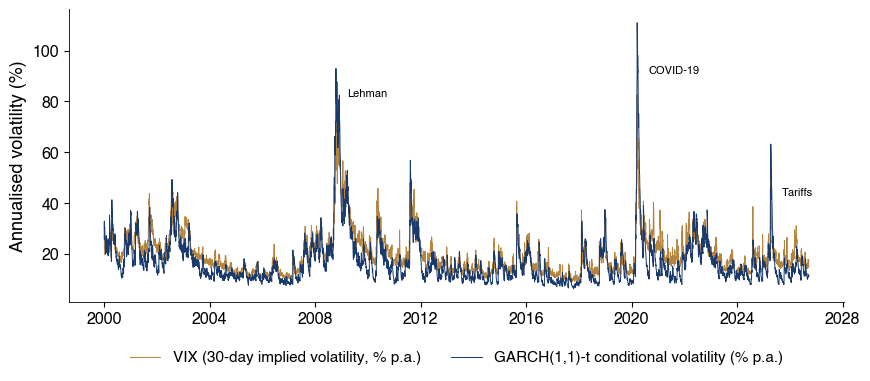

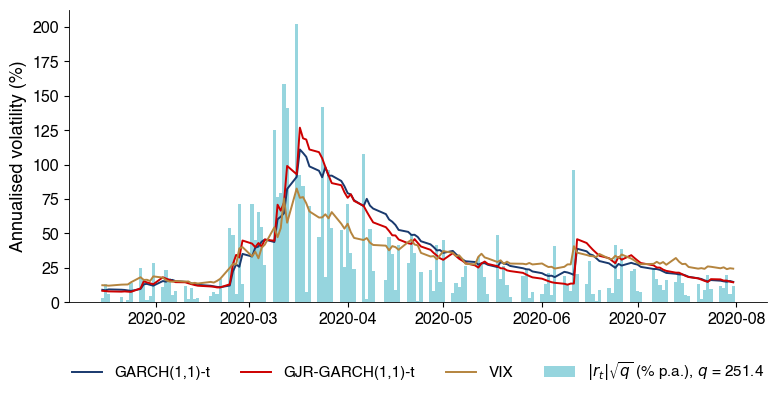

GARCH-t volatility and the VIX, 2000-2026
  Correlation of GARCH-t volatility and the VIX: 0.8854
  Mean VIX (%): 19.7995
  Mean GARCH-t volatility (%): 16.9763
  Highest GARCH-t volatility (%): 111.0262
  Date of the highest GARCH-t volatility: 2020-03-17
  Lowest GARCH-t volatility (%): 6.2457
  Date of the lowest GARCH-t volatility: 2017-10-20
  Share of days with the VIX above GARCH-t: 0.8365
COVID-19, January-July 2020
  Peak GARCH-t volatility, 2020 (%): 111.0262
  Peak GJR-t volatility, 2020 (%): 126.8738
  Peak VIX, 2020: 82.6900
  Date of the VIX peak: 2020-03-16
  Date of the GARCH-t peak: 2020-03-17
  Lowest return, 2020 (%): -12.7652
  Date of the lowest return: 2020-03-16
  VIX on 21 Feb 2020: 17.0800
  VIX on 24 Feb 2020: 25.0300
  GARCH-t volatility on 24 Feb 2020 (%): 12.1941
  GARCH-t volatility on 25 Feb 2020 (%): 22.5494
  Return on 24 Feb 2020 (%): -3.4088


In [11]:
def fig_sp500_vol(fits):
    f = fits[('sp500', 'GARCH', 't')]
    vol = f.sigma * np.sqrt(PPY['sp500'])
    vix = load_vix().reindex(vol.index).dropna()
    fig, ax = plt.subplots(figsize=(10, 3.8))
    ax.plot(vix.index, vix.values, color=Amber, lw=0.7, label='VIX (30-day implied volatility, % p.a.)')
    ax.plot(vol.index, vol.values, color=MainBlue, lw=0.7, label='GARCH(1,1)-t conditional volatility (% p.a.)')
    for d, lab in [('2008-10-15', 'Lehman'), ('2020-03-16', 'COVID-19'), ('2025-04-08', 'Tariffs')]:
        ax.annotate(lab, (pd.Timestamp(d), vol.loc[:d].iloc[-1]), xytext=(8, 0), textcoords='offset points',
                    fontsize=8, color='black')
    ax.set_ylabel('Annualised volatility (%)')
    legend_outside_bottom(ax, ncol=2, y=-0.12)
    save_fig('ch5_sp500_vol')
    common = vol.reindex(vix.index)
    NUM['vix'] = {'corr': float(np.corrcoef(common, vix)[0, 1]), 'mean_vix': float(vix.mean()),
                  'mean_garch': float(common.mean()), 'max_garch': float(vol.max()), 'max_garch_date': str(vol.idxmax().date()),
                  'min_garch': float(vol.min()), 'min_garch_date': str(vol.idxmin().date()),
                  'share_vix_above': float((vix > common).mean())}


def fig_covid(fits):
    g, j = fits[('sp500', 'GARCH', 't')], fits[('sp500', 'GJR', 't')]
    a, b = '2020-01-15', '2020-07-31'
    ppy = np.sqrt(PPY['sp500'])
    vix = load_vix().loc[a:b]
    r = rets['sp500'].loc[a:b]
    fig, ax = plt.subplots(figsize=(9, 3.8))
    ax.bar(r.index, np.abs(r.values) * ppy, color=Teal, alpha=0.45, width=1.0, label=r'$|r_t|\sqrt{q}$ (% p.a.), $q$ = ' + f'{PPY["sp500"]:.1f}')
    ax.plot(g.sigma.loc[a:b] * ppy, color=MainBlue, label='GARCH(1,1)-t')
    ax.plot(j.sigma.loc[a:b] * ppy, color=IDAred, label='GJR-GARCH(1,1)-t')
    ax.plot(vix, color=Amber, label='VIX')
    ax.set_ylabel('Annualised volatility (%)')
    legend_outside_bottom(ax, ncol=4, y=-0.15)
    save_fig('ch5_covid')
    NUM['covid'] = {'garch_max': float(g.sigma.loc[a:b].max() * ppy), 'gjr_max': float(j.sigma.loc[a:b].max() * ppy),
                    'vix_max': float(vix.max()), 'vix_max_date': str(vix.idxmax().date()),
                    'garch_max_date': str(g.sigma.loc[a:b].idxmax().date()),
                    'rmin': float(r.min()), 'rmin_date': str(r.idxmin().date()),
                    'vix_0221': float(vix.loc['2020-02-21']), 'vix_0224': float(vix.loc['2020-02-24']),
                    'garch_0224': float(g.sigma.loc['2020-02-24'] * ppy), 'garch_0225': float(g.sigma.loc['2020-02-25'] * ppy),
                    'r_0224': float(rets['sp500'].loc['2020-02-24'])}


fig_sp500_vol(FITS)
fig_covid(FITS)
show('GARCH-t volatility and the VIX, 2000-2026', NUM['vix'])
show('COVID-19, January-July 2020', NUM['covid'])

## 7. BET, Bitcoin, EUR/RON and gold

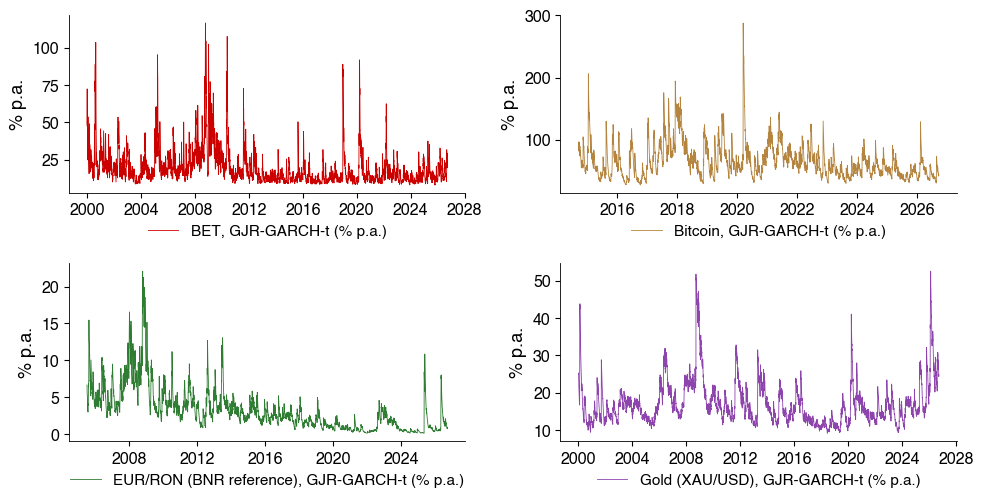

Gold: GJR-t volatility peaks (% p.a.): {'2008': 51.8, '2013': 31.5, '2020': 41.0, '2026': 52.6}


In [12]:
def fig_markets_vol(fits):
    fig, axes = plt.subplots(2, 2, figsize=(10, 5.2))
    for ax, k in zip(axes.ravel(), ['bet', 'btc', 'eurron', 'gold']):
        f = fits[(k, 'GJR', 't')]
        v = f.sigma * np.sqrt(PPY[k])
        ax.plot(v.index, v.values, color=COL[k], lw=0.6, label=f'{LABELS[k]}, GJR-GARCH-t (% p.a.)')
        ax.set_ylabel('% p.a.')
        ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), frameon=False)
    fig.tight_layout()
    save_fig('ch5_markets_vol')
    v = fits[('gold', 'GJR', 't')].sigma * np.sqrt(PPY['gold'])
    NUM['gold_peaks'] = {str(y): float(v.loc[str(y)].max()) for y in [2008, 2013, 2020, 2026]}


fig_markets_vol(FITS)
print('Gold: GJR-t volatility peaks (% p.a.):', {y: round(v, 1) for y, v in NUM['gold_peaks'].items()})

## 8. Asymmetry: GJR-GARCH, EGARCH and the news impact curve

- Likelihood ratio test of GJR against GARCH: $LR = 2(\ell_{GJR} - \ell_{GARCH}) \sim \chi^2_1$.

market               sp500        bet     bettr        btc    eurron  \
gjr_alpha            0.000      0.172     0.144      0.113     0.103   
gjr_gamma            0.205      0.043     0.111     -0.013     0.039   
gjr_gamma_t         10.028      2.051     2.922     -0.721     3.031   
gjr_beta             0.881      0.796     0.711      0.894     0.878   
gjr_persistence      0.983      0.990     0.911      1.000     1.000   
lr                 235.653      4.926    10.343      0.662     9.293   
lr_p                 0.000      0.026     0.001      0.416     0.002   
eg_alpha             0.138      0.336     0.338      0.246     0.553   
eg_gamma            -0.165     -0.028    -0.063      0.015    -0.040   
eg_gamma_t         -15.203     -2.631    -3.469      1.181    -2.474   
eg_beta              0.979      0.962     0.903      0.985     0.982   
bic_garch        18169.006  19513.690  7065.820  21502.527 -5925.951   
bic_gjr          17942.166  19517.569  7063.481  21510.251 -5926

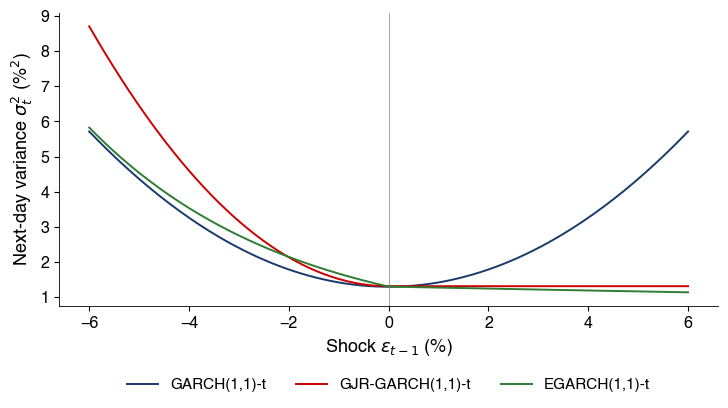

News impact, S&P 500 (variance, %^2)
  Long-run variance: 1.4714
  GJR variance after a -3% shock: 3.1615
  GJR variance after a +3% shock: 1.3148
  EGARCH variance after a -3% shock: 2.7550
  EGARCH variance after a +3% shock: 1.2191
  GARCH variance after a shock of +/-3%: 2.4022


In [13]:
def asym_table(fits):
    rows = []
    for k in ORDER:
        g, j, e = fits[(k, 'GARCH', 't')], fits[(k, 'GJR', 't')], fits[(k, 'EGARCH', 't')]
        lr = 2 * (j.loglik - g.loglik)
        rows.append(dict(market=k, gjr_alpha=j.params['alpha[1]'], gjr_gamma=j.params['gamma[1]'],
                         gjr_gamma_t=j.tvalues['gamma[1]'], gjr_beta=j.params['beta[1]'],
                         gjr_persistence=j.persistence, lr=lr, lr_p=1 - stats.chi2.cdf(lr, 1),
                         eg_alpha=e.params['alpha[1]'], eg_gamma=e.params['gamma[1]'], eg_gamma_t=e.tvalues['gamma[1]'],
                         eg_beta=e.params['beta[1]'], bic_garch=g.bic, bic_gjr=j.bic, bic_egarch=e.bic))
    t = pd.DataFrame(rows).set_index('market')
    t.to_csv(os.path.join(TABLE_DIR, 'ch5_asym_table.csv'))
    return t


def fig_nic(fits):
    eps = np.linspace(-6, 6, 241)
    fig, ax = plt.subplots(figsize=(8.5, 3.8))
    for (vol, c, lab) in [('GARCH', MainBlue, 'GARCH(1,1)-t'), ('GJR', IDAred, 'GJR-GARCH(1,1)-t'),
                          ('EGARCH', Forest, 'EGARCH(1,1)-t')]:
        f = fits[('sp500', vol, 't')]
        ax.plot(eps, news_impact(f, eps), color=c, label=lab)
    ax.set_xlabel(r'Shock $\varepsilon_{t-1}$ (%)')
    ax.set_ylabel(r'Next-day variance $\sigma_t^2$ (%$^2$)')
    ax.axvline(0, color=Gray, lw=0.5)
    legend_outside_bottom(ax, ncol=3, y=-0.2)
    save_fig('ch5_nic')
    fj = fits[('sp500', 'GJR', 't')]
    s2 = rets['sp500'].var()
    NUM['nic'] = {'s2bar': float(s2), 'gjr_m3': float(news_impact(fj, np.array([-3.0]))[0]),
                  'gjr_p3': float(news_impact(fj, np.array([3.0]))[0]),
                  'eg_m3': float(news_impact(fits[('sp500', 'EGARCH', 't')], np.array([-3.0]))[0]),
                  'eg_p3': float(news_impact(fits[('sp500', 'EGARCH', 't')], np.array([3.0]))[0]),
                  'g_pm3': float(news_impact(fits[('sp500', 'GARCH', 't')], np.array([3.0]))[0])}


at = asym_table(FITS)
print(at.round(3).T)
fig_nic(FITS)
show('News impact, S&P 500 (variance, %^2)', NUM['nic'])

## 9. Innovations and diagnostics

- Standardised residuals $\hat z_t = \hat\varepsilon_t/\hat\sigma_t$: level, squares, signs (Engle–Ng) and distribution.

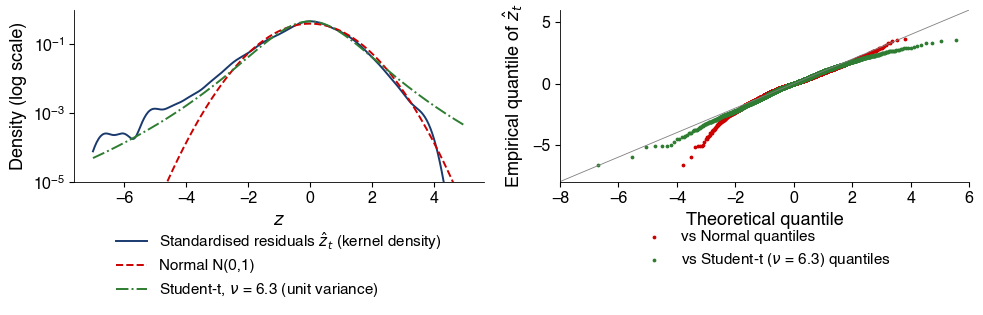

Standardised residuals, S&P 500
  Excess kurtosis of z: 1.7301
  Skewness of z: -0.5309
  Jarque-Bera statistic: 1152.7163
  Smallest z: -6.6230
  Date of the smallest z: 2007-02-27
  Student-t degrees of freedom nu (GARCH-t): 6.2562
  Excess kurtosis of the returns: 10.6661
  Residuals below -4: 15
  Expected below -4, Normal: 0.2126
  Expected below -4, Student-t: 8.5323
  Skewed-t degrees of freedom nu (GJR): 7.7023
  Skewed-t asymmetry lambda (GJR): -0.1497


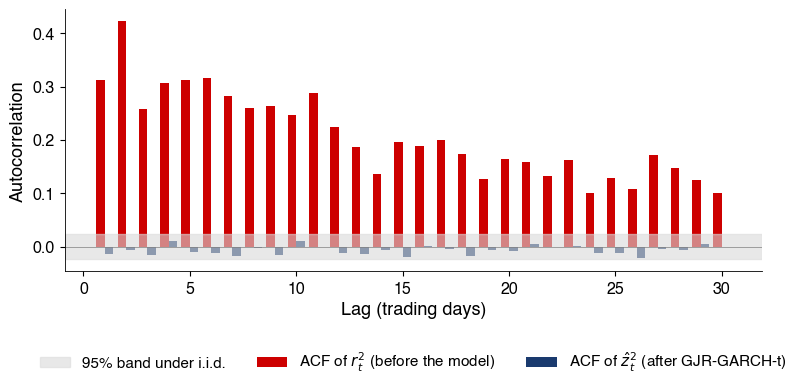

,market,vol,dist,Q10_z,Q10_z_p,Q10_z2,Q10_z2_p,LM5,LM5_p,z_kurt,z_skew,sign_t,neg_size_t,pos_size_t,joint,joint_p
0,sp500,GARCH,normal,21.198,0.020,16.396,0.089,8.036,0.154,1.730,-0.531,3.636,0.467,-2.329,41.787,0.000
1,sp500,GARCH,t,21.858,0.016,13.610,0.192,5.799,0.326,2.009,-0.579,3.564,1.129,-2.613,40.665,0.000
2,sp500,GJR,t,22.327,0.014,10.244,0.419,4.460,0.485,2.353,-0.632,3.612,3.341,-1.632,28.061,0.000
3,sp500,EGARCH,t,27.638,0.002,10.548,0.394,8.244,0.143,2.804,-0.686,2.037,2.049,-1.075,9.879,0.020
4,sp500,GJR,skewt,19.745,0.032,10.693,0.382,5.031,0.412,2.340,-0.630,3.906,3.597,-1.681,31.781,0.000
5,bet,GARCH,normal,113.504,0.000,8.407,0.589,5.396,0.370,6.200,-0.506,1.468,-1.519,0.232,9.302,0.026
6,bet,GARCH,t,114.647,0.000,8.332,0.596,5.572,0.350,6.512,-0.541,1.597,-1.913,0.684,11.637,0.009
7,bet,GJR,t,116.622,0.000,9.153,0.518,6.111,0.296,5.963,-0.468,1.459,-1.510,0.970,7.843,0.049
8,bet,EGARCH,t,117.571,0.000,12.191,0.272,9.943,0.077,6.028,-0.468,1.502,-2.356,1.801,13.450,0.004
9,bet,GJR,skewt,116.770,0.000,8.975,0.535,5.908,0.315,6.050,-0.479,1.094,-1.661,0.695,6.980,0.073


In [14]:
def fig_resid_density(fits):
    fn = fits[('sp500', 'GARCH', 'normal')]
    z = fn.z.dropna().values
    ft = fits[('sp500', 'GJR', 'skewt')]
    nu_t = fits[('sp500', 'GARCH', 't')].params['nu']
    grid = np.linspace(-7, 5, 400)
    kde = stats.gaussian_kde(z, bw_method=0.25)
    st = stats.t(df=nu_t, scale=np.sqrt((nu_t - 2) / nu_t))
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
    ax = axes[0]
    ax.semilogy(grid, kde(grid), color=MainBlue, label='Standardised residuals $\\hat z_t$ (kernel density)')
    ax.semilogy(grid, stats.norm.pdf(grid), color=IDAred, ls='--', label='Normal N(0,1)')
    ax.semilogy(grid, st.pdf(grid), color=Forest, ls='-.', label=f'Student-t, $\\nu$ = {nu_t:.1f} (unit variance)')
    ax.set_ylim(1e-5, 1)
    ax.set_xlabel('$z$')
    ax.set_ylabel('Density (log scale)')
    legend_outside_bottom(ax, ncol=1, y=-0.2)
    ax = axes[1]
    q = np.sort(z)
    pr = (np.arange(1, len(q) + 1) - 0.5) / len(q)
    ax.scatter(stats.norm.ppf(pr), q, s=3, color=IDAred, label='vs Normal quantiles')
    ax.scatter(st.ppf(pr), q, s=3, color=Forest, label=f'vs Student-t ($\\nu$ = {nu_t:.1f}) quantiles')
    lim = [-8, 6]
    ax.plot(lim, lim, color=Gray, lw=0.6)
    ax.set_xlim(lim)
    ax.set_ylim(lim)
    ax.set_xlabel('Theoretical quantile')
    ax.set_ylabel('Empirical quantile of $\\hat z_t$')
    legend_outside_bottom(ax, ncol=1, y=-0.2)
    fig.tight_layout()
    save_fig('ch5_innovations')
    jb = stats.jarque_bera(z)
    NUM['innov'] = {'z_kurt': float(stats.kurtosis(z)), 'z_skew': float(stats.skew(z)), 'jb': float(jb[0]),
                    'z_min': float(z.min()), 'z_min_date': str(fn.z.idxmin().date()), 'nu_t': float(nu_t),
                    'r_kurt': float(stats.kurtosis(rets['sp500'])),
                    'n_below4': int((z < -4).sum()), 'exp_below4_normal': float(len(z) * stats.norm.cdf(-4)),
                    'exp_below4_t': float(len(z) * st.cdf(-4)),
                    'skewt_eta': float(ft.params['eta']), 'skewt_lambda': float(ft.params['lambda'])}


def diagnostics(fits):
    rows = []
    for k in MAIN + ['bettr']:
        for vol, dist in [('GARCH', 'normal'), ('GARCH', 't'), ('GJR', 't'), ('EGARCH', 't'), ('GJR', 'skewt')]:
            f = fits[(k, vol, dist)]
            z = f.z.dropna()
            q, qp = ljung_box(z, 10)
            q2, q2p = ljung_box(z ** 2, 10)
            lm, lmp = arch_lm(z, 5)
            sb = sign_bias_test(z, f.eps)
            rows.append(dict(market=k, vol=vol, dist=dist, Q10_z=q, Q10_z_p=qp, Q10_z2=q2, Q10_z2_p=q2p,
                             LM5=lm, LM5_p=lmp, z_kurt=stats.kurtosis(z), z_skew=stats.skew(z), **sb))
    t = pd.DataFrame(rows)
    t.to_csv(os.path.join(TABLE_DIR, 'ch5_diagnostics.csv'), index=False)
    return t


def fig_diag_acf(fits):
    r = rets['sp500']
    f = fits[('sp500', 'GJR', 't')]
    z = f.z.dropna()
    L = 30
    lags = np.arange(1, L + 1)
    fig, ax = plt.subplots(figsize=(9, 3.4))
    ax.bar(lags - 0.2, acf(r ** 2, L), width=0.4, color=IDAred, label='ACF of $r_t^2$ (before the model)')
    ax.bar(lags + 0.2, acf(z ** 2, L), width=0.4, color=MainBlue, label=r'ACF of $\hat z_t^2$ (after GJR-GARCH-t)')
    b = 1.96 / np.sqrt(len(z))
    ax.axhspan(-b, b, color=LightGray, alpha=0.6, label='95% band under i.i.d.')
    ax.axhline(0, color=Gray, lw=0.5)
    ax.set_xlabel('Lag (trading days)')
    ax.set_ylabel('Autocorrelation')
    legend_outside_bottom(ax, ncol=3, y=-0.25)
    save_fig('ch5_diag_acf')


fig_resid_density(FITS)
show('Standardised residuals, S&P 500', NUM['innov'])
dg = diagnostics(FITS)
fig_diag_acf(FITS)
dg.round(3)

## 10. Forecast evaluation, S&P 500, 2016–2026

- Yearly re-estimation on all data since 2000; one-day and 22-day forecasts.
- QLIKE $= r_t^2/h_t + \ln h_t$ (Patton, 2011), Diebold–Mariano tests (HAC, 5 lags), Mincer–Zarnowitz regressions.
- Proxy $r_t^2$ for the variance: the mean is ignored, since $\hat\mu^2 \approx 0.006$ against an average daily variance of about 1.47 (a bias below 1%).
- The log Mincer–Zarnowitz regression at 22 days is descriptive: $\mathrm{E}[\ln Y] \neq \ln \mathrm{E}[Y]$, so the 45-degree line is only a reference.

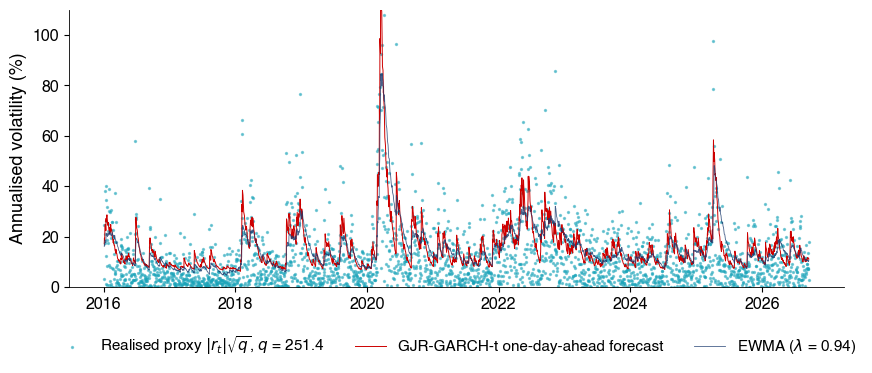

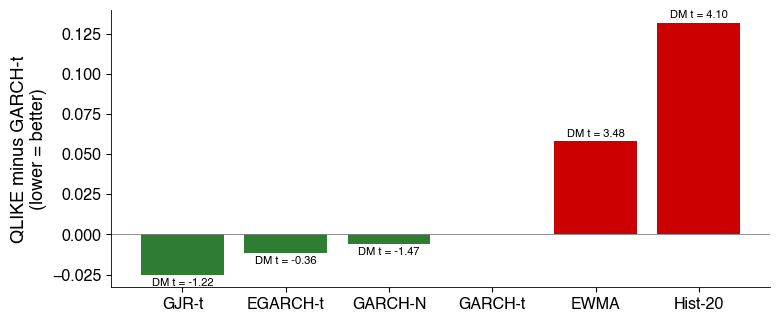

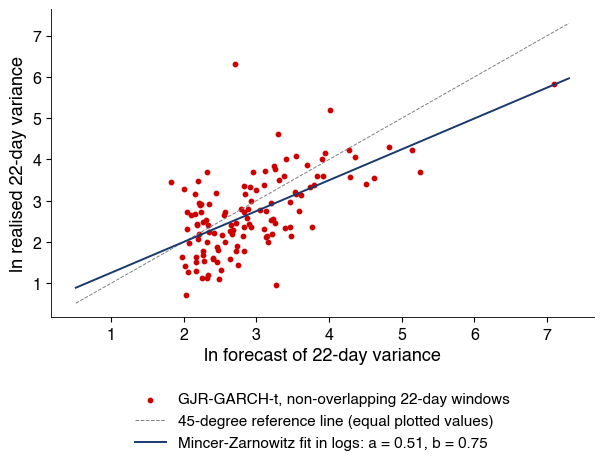

           qlike      mse  dm_diff    dm_t    dm_p    mz_a    mz_b  mz_b_se  \
model                                                                         
GARCH-N   0.7510  22.2768  -0.0060 -1.4733  0.1407  0.0250  0.9734   0.2728   
GARCH-t   0.7570  22.7593   0.0000     NaN     NaN  0.0844  0.8799   0.2501   
GJR-t     0.7319  21.8105  -0.0250 -1.2177  0.2233  0.1298  0.8352   0.2168   
EGARCH-t  0.7454  21.3030  -0.0115 -0.3584  0.7200 -0.2332  1.2381   0.3059   
EWMA      0.8149  24.6689   0.0579  3.4770  0.0005  0.1413  0.8863   0.2723   
Hist-20   0.8888  26.1346   0.1319  4.1020  0.0000  0.3997  0.6845   0.2243   

           mz_r2  mz_wald_p  
model                        
GARCH-N   0.2498     0.9951  
GARCH-t   0.2380     0.8042  
GJR-t     0.2764     0.6802  
EGARCH-t  0.2933     0.7130  
EWMA      0.1718     0.6851  
Hist-20   0.1519     0.0277  


,n,mz_a,mz_b,mz_b_se,mz_r2,mz_wald_p,lmz_a,lmz_b,lmz_b_se,lmz_r2,lmz_wald_p,qlike
model,,,,,,,,,,,,
GARCH-N,122,16.441,0.363,0.020,0.231,0.0,0.173,0.839,0.089,0.347,0.0,4.200
GARCH-t,122,17.073,0.307,0.018,0.230,0.0,0.447,0.744,0.076,0.353,0.0,4.208
GJR-t,122,18.721,0.269,0.012,0.242,0.0,0.506,0.748,0.068,0.379,0.0,4.237
EWMA,122,15.752,0.407,0.055,0.202,0.0,0.937,0.631,0.064,0.357,0.0,4.355


In [15]:
MODELS_OOS = [('GARCH', 'normal', 'GARCH-N'), ('GARCH', 't', 'GARCH-t'), ('GJR', 't', 'GJR-t'), ('EGARCH', 't', 'EGARCH-t')]


def oos_forecasts(k='sp500', first_year=2016, H=22):
    r = rets[k]
    idx = r.index
    last_year = idx[-1].year
    out1 = {lab: pd.Series(np.nan, index=idx) for *_, lab in MODELS_OOS}
    outH = {lab: pd.Series(np.nan, index=idx) for *_, lab in MODELS_OOS if lab != 'EGARCH-t'}
    for y in range(first_year, last_year + 1):
        start = idx[idx < f'{y}-01-01'][-1]
        end = idx[idx <= f'{y}-12-31'][-1]
        orig = idx[(idx >= start) & (idx < end)]
        for vol, dist, lab in MODELS_OOS:
            f = fit_garch(r, vol, dist, last_obs=idx[idx >= f'{y}-01-01'][0])
            hh = 1 if vol == 'EGARCH' else H
            fc = f.res.forecast(horizon=hh, start=start, reindex=False).variance / f.c ** 2
            fc = fc.loc[orig]
            pos = idx.get_indexer(fc.index)
            out1[lab].iloc[pos + 1] = fc.iloc[:, 0].values
            if hh == H and lab in outH:
                outH[lab].loc[fc.index] = fc.sum(axis=1).values      # cumulative variance over t+1..t+H, at origin t
    ew = ewma_variance(r)
    hist = (r ** 2).rolling(20).mean().shift(1)
    out1['EWMA'] = ew.reindex(idx)
    out1['Hist-20'] = hist
    outH['EWMA'] = (ew.shift(-1) * H).reindex(idx)       # the EWMA forecast is flat across horizons
    f1 = pd.DataFrame(out1).loc[f'{first_year}-01-01':].dropna()
    fH = pd.DataFrame(outH).dropna()
    return f1, fH


def forecast_eval(k='sp500', first_year=2016, H=22):
    r = rets[k]
    f1, fH = oos_forecasts(k, first_year, H)
    proxy = (r ** 2).reindex(f1.index)
    rows = []
    base = qlike(proxy, f1['GARCH-t'])
    for m in f1.columns:
        L = qlike(proxy, f1[m])
        mz = mz_regression(proxy, f1[m])
        dm = dm_test(L, base) if m != 'GARCH-t' else {'mean_diff': 0.0, 't': np.nan, 'p': np.nan}
        rows.append(dict(model=m, qlike=L.mean(), mse=((proxy - f1[m]) ** 2).mean(), dm_diff=dm['mean_diff'],
                         dm_t=dm['t'], dm_p=dm['p'], mz_a=mz['a'], mz_b=mz['b'], mz_b_se=mz['b_se'], mz_r2=mz['r2'],
                         mz_wald_p=mz['wald_p']))
    t = pd.DataFrame(rows).set_index('model')
    # horizon H: cumulative variances, non-overlapping origins (every H days)
    rH = (r ** 2).rolling(H).sum().shift(-H)
    origins = fH.index[::H]
    rows = []
    for m in fH.columns:
        y, x = rH.reindex(origins), fH[m].reindex(origins)
        okk = y.notna() & x.notna()
        mz = mz_regression(y[okk], x[okk], lags=2)
        lmz = mz_regression(np.log(y[okk]), np.log(x[okk]), lags=2)
        rows.append(dict(model=m, n=int(okk.sum()), mz_a=mz['a'], mz_b=mz['b'], mz_b_se=mz['b_se'], mz_r2=mz['r2'],
                         mz_wald_p=mz['wald_p'], lmz_a=lmz['a'], lmz_b=lmz['b'], lmz_b_se=lmz['b_se'], lmz_r2=lmz['r2'],
                         lmz_wald_p=lmz['wald_p'], qlike=qlike(y[okk], x[okk]).mean()))
    tH = pd.DataFrame(rows).set_index('model')
    t.to_csv(os.path.join(TABLE_DIR, 'ch5_forecast_eval.csv'))
    tH.to_csv(os.path.join(TABLE_DIR, 'ch5_forecast_eval_22d.csv'))
    NUM['oos'] = {'start': str(f1.index[0].date()), 'end': str(f1.index[-1].date()), 'n': len(f1),
                  'n22': int(tH['n'].iloc[0])}
    # chart 1: forecast vs |r|
    ppy = np.sqrt(PPY[k])
    fig, ax = plt.subplots(figsize=(10, 3.6))
    ax.scatter(f1.index, np.sqrt(proxy) * ppy, s=2, color=Teal, alpha=0.5, label=r'Realised proxy $|r_t|\sqrt{q}$, $q$ = ' + f'{PPY[k]:.1f}')
    ax.plot(f1.index, np.sqrt(f1['GJR-t']) * ppy, color=IDAred, lw=0.7, label='GJR-GARCH-t one-day-ahead forecast')
    ax.plot(f1.index, np.sqrt(f1['EWMA']) * ppy, color=MainBlue, lw=0.6, alpha=0.8, label='EWMA ($\\lambda$ = 0.94)')
    ax.set_ylim(0, 110)
    ax.set_ylabel('Annualised volatility (%)')
    legend_outside_bottom(ax, ncol=3, y=-0.12)
    save_fig('ch5_forecast_oos')
    # chart 2: relative QLIKE
    fig, ax = plt.subplots(figsize=(8.5, 3.6))
    order = t['qlike'].sort_values().index
    vals = t.loc[order, 'dm_diff']
    cols = [Forest if v < 0 else (MainBlue if v == 0 else IDAred) for v in vals]
    ax.bar(order, vals, color=cols)
    for i, m in enumerate(order):
        if m != 'GARCH-t':
            ax.annotate(f"DM t = {t.loc[m, 'dm_t']:.2f}", (i, vals[m]), ha='center',
                        va='bottom' if vals[m] >= 0 else 'top', fontsize=8, xytext=(0, 2 if vals[m] >= 0 else -2),
                        textcoords='offset points')
    ax.axhline(0, color=Gray, lw=0.6)
    ax.set_ylabel('QLIKE minus GARCH-t\n(lower = better)')
    save_fig('ch5_qlike')
    # chart 3: 22-day Mincer-Zarnowitz, in logs
    fig, ax = plt.subplots(figsize=(7, 4))
    y, x = rH.reindex(origins), fH['GJR-t'].reindex(origins)
    okk = y.notna() & x.notna()
    ly, lx = np.log(y[okk]), np.log(x[okk])
    ax.scatter(lx, ly, s=10, color=IDAred, label='GJR-GARCH-t, non-overlapping 22-day windows')
    lim = [min(lx.min(), ly.min()) - 0.2, max(lx.max(), ly.max()) + 0.2]
    ax.plot(lim, lim, color=Gray, lw=0.7, ls='--', label='45-degree reference line (equal plotted values)')
    a, b = tH.loc['GJR-t', 'lmz_a'], tH.loc['GJR-t', 'lmz_b']
    xx = np.linspace(*lim, 10)
    ax.plot(xx, a + b * xx, color=MainBlue, label=f'Mincer-Zarnowitz fit in logs: a = {a:.2f}, b = {b:.2f}')
    ax.set_xlabel('ln forecast of 22-day variance')
    ax.set_ylabel('ln realised 22-day variance')
    legend_outside_bottom(ax, ncol=1, y=-0.2)
    save_fig('ch5_mz')
    return t, tH


fe, fe22 = forecast_eval()
print(fe.round(4))
fe22.round(3)

## 11. GARCH-in-mean and long memory

- $r_t = c + \kappa\sigma_t + \varepsilon_t$; ACF of $|r_t|$ in the data and in paths simulated from GARCH and FIGARCH.

GARCH-in-mean with sigma_t: kappa = 0.0960, t = 3.02, p = 0.0025
GARCH-in-mean with sigma_t^2: kappa = 0.0281, t = 2.35, p = 0.0188


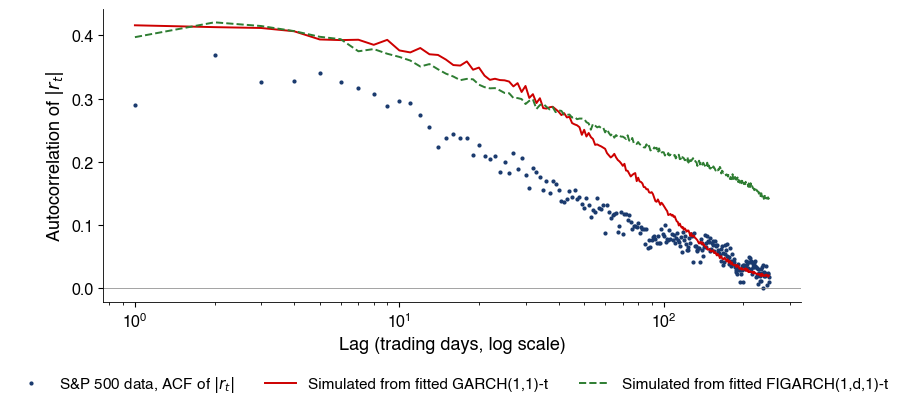

Long memory, S&P 500
  ACF of |r_t|, lag 1, data: 0.2892
  ACF of |r_t|, lag 100, data: 0.0822
  ACF of |r_t|, lag 250, data: 0.0093
  ACF of |r_t|, lag 1, GARCH: 0.4161
  ACF of |r_t|, lag 100, GARCH: 0.1302
  ACF of |r_t|, lag 250, GARCH: 0.0197
  ACF of |r_t|, lag 1, FIGARCH: 0.3973
  ACF of |r_t|, lag 100, FIGARCH: 0.2148
  ACF of |r_t|, lag 250, FIGARCH: 0.1440
  FIGARCH memory parameter d: 0.6047
  s.e. of d: 0.0620
  BIC, FIGARCH: 18134.7759
  BIC, GARCH: 18169.0063


In [16]:
def garch_in_mean():
    r = rets['sp500']
    out = {}
    for form in ['vol', 'var']:
        m = ARCHInMean(r, lags=0, form=form, volatility=GARCH(), distribution=StudentsT())
        res = m.fit(disp='off')
        out[form] = {'kappa': float(res.params['kappa']), 't': float(res.tvalues['kappa']),
                     'p': float(res.pvalues['kappa']), 'const': float(res.params['Const'])}
    NUM['garch_m'] = out


def fig_long_memory(fits):
    r = rets['sp500']
    L = 250
    emp = acf(np.abs(r), L)
    f = fits[('sp500', 'GARCH', 't')]
    p = f.params
    sim = ZeroMean(None, volatility=GARCH(), distribution=StudentsT(seed=np.random.default_rng(SEED)))
    x = sim.simulate([p['omega'], p['alpha[1]'], p['beta[1]'], p['nu']], nobs=400_000, burn=2000)['data'].values
    ga = acf(np.abs(x), L)
    ff = arch_model(r, vol='FIGARCH', p=1, q=1, dist='t').fit(disp='off')
    fp = ff.params
    simf = ZeroMean(None, volatility=FIGARCH(), distribution=StudentsT(seed=np.random.default_rng(SEED + 1)))
    xf = simf.simulate([fp['omega'], fp['phi'], fp['d'], fp['beta'], fp['nu']], nobs=400_000, burn=5000)['data'].values
    fa = acf(np.abs(xf), L)
    lags = np.arange(1, L + 1)
    fig, ax = plt.subplots(figsize=(9, 3.8))
    ax.plot(lags, emp, color=MainBlue, marker='o', ms=2, lw=0, label='S&P 500 data, ACF of $|r_t|$')
    ax.plot(lags, ga, color=IDAred, label='Simulated from fitted GARCH(1,1)-t')
    ax.plot(lags, fa, color=Forest, ls='--', label='Simulated from fitted FIGARCH(1,d,1)-t')
    ax.axhline(0, color=Gray, lw=0.5)
    ax.set_xscale('log')
    ax.set_xlabel('Lag (trading days, log scale)')
    ax.set_ylabel('Autocorrelation of $|r_t|$')
    legend_outside_bottom(ax, ncol=3, y=-0.2)
    save_fig('ch5_long_memory')
    NUM['long_memory'] = {'emp_1': emp[0], 'emp_100': emp[99], 'emp_250': emp[249], 'garch_1': ga[0], 'garch_100': ga[99],
                          'garch_250': ga[249], 'fig_1': fa[0], 'fig_100': fa[99], 'fig_250': fa[249],
                          'd': float(fp['d']), 'd_se': float(ff.std_err['d']), 'fig_bic': float(ff.bic),
                          'garch_bic': float(f.bic)}


garch_in_mean()
for k, lab in [('vol', 'sigma_t'), ('var', 'sigma_t^2')]:
    m = NUM['garch_m'][k]
    print(f"GARCH-in-mean with {lab}: kappa = {m['kappa']:.4f}, t = {m['t']:.2f}, p = {m['p']:.4f}")
fig_long_memory(FITS)
show('Long memory, S&P 500', NUM['long_memory'])

## 12. Asymptotic inference for GARCH

- Gaussian QMLE: robust / classical standard error $\approx \sqrt{(\kappa_z - 1)/2}$; boundary LR (Normal vs Student-t); delta method for long-run volatility and half-life; moments and $\rho_1(\varepsilon^2)$ of GARCH-N.
- Squared-residual portmanteau with estimated parameters (Li and Mak, 1994); GJR persistence with skewed-t innovations; Giacomini–White tests (rolling 1000-day window) and the 90% Model Confidence Set on QLIKE.

In [17]:
from scipy import integrate
from arch.bootstrap import MCS
INF = {}


def qmle_efficiency():
    """Gaussian QMLE: avar = (kappa_z - 1) J^{-1}; classical (inverse Hessian) = 2 J^{-1}; s.e. ratio sqrt((kappa_z-1)/2)."""
    out = {}
    for k in ['sp500', 'btc']:
        f = fit_garch(rets[k], 'GARCH', 'normal')
        cl = f.res.model.fit(disp='off', cov_type='classic', starting_values=f.res.params.values)
        z = f.z.dropna()
        kz = float(stats.kurtosis(z, fisher=False))
        out[k] = {'kappa_z': kz, 'theory_ratio': float(np.sqrt((kz - 1) / 2)),
                  'ratio_alpha': float(f.se['alpha[1]'] / cl.std_err['alpha[1]']),
                  'ratio_beta': float(f.se['beta[1]'] / cl.std_err['beta[1]']),
                  'alpha': float(f.params['alpha[1]']), 'beta': float(f.params['beta[1]'])}
        # stability of the sample kurtosis: first half vs full sample
        out[k]['kappa_half'] = float(stats.kurtosis(z.iloc[:len(z) // 2], fisher=False))
    INF['qmle'] = out


def boundary_tests():
    """LR for Normal (1/nu = 0) against Student-t: 1/nu >= 0, so the limit law is 1/2 chi2(0) + 1/2 chi2(1)."""
    out = {'crit_mix': float(stats.chi2.ppf(0.90, 1)), 'crit_chi2': float(stats.chi2.ppf(0.95, 1))}
    for k in ['sp500', 'btc']:
        fn, ft = fit_garch(rets[k], 'GARCH', 'normal'), fit_garch(rets[k], 'GARCH', 't')
        lr = 2 * (ft.loglik - fn.loglik)
        out[k] = {'lr': float(lr), 'p_mix': float(0.5 * stats.chi2.sf(lr, 1)), 'nu': float(ft.params['nu'])}
    g = fit_garch(rets['sp500'], 'GJR', 't')
    out['gjr_alpha'] = float(g.params['alpha[1]'])
    INF['boundary'] = out


def delta_method():
    """Delta method from the robust covariance of (omega, alpha, beta), GARCH(1,1)-t, S&P 500."""
    f = fit_garch(rets['sp500'], 'GARCH', 't')
    p = f.params
    V = f.res.param_cov.loc[['omega', 'alpha[1]', 'beta[1]'], ['omega', 'alpha[1]', 'beta[1]']].values / f.c ** 2
    om, a, b = p['omega'], p['alpha[1]'], p['beta[1]']
    pers = a + b
    se_p = float(np.sqrt(V[1:, 1:].sum()))
    s2 = om / (1 - pers)
    g = np.array([1 / (1 - pers), om / (1 - pers) ** 2, om / (1 - pers) ** 2])
    se_s2 = float(np.sqrt(g @ V @ g))
    vol = np.sqrt(PPY['sp500'] * s2)
    se_vol = PPY['sp500'] * se_s2 / (2 * vol)
    hl = half_life(pers)
    dh = -np.log(0.5) / (pers * np.log(pers) ** 2)
    lo, hi = pers - 1.96 * se_p, pers + 1.96 * se_p
    INF['delta'] = {'pers': float(pers), 'se_p': se_p, 's2': float(s2), 'se_s2': se_s2, 'vol': float(vol),
                    'se_vol': float(se_vol), 'hl': float(hl), 'dh': float(dh), 'se_hl': float(dh * se_p),
                    'p_lo': float(lo), 'p_hi': float(hi), 'hl_lo': float(half_life(lo)),
                    'grad_om': float(g[0]), 'grad_ab': float(g[1])}


def moments_garch_n():
    """GARCH(1,1) with Normal innovations: (alpha+beta)^2 + 2 alpha^2, K and rho_1(eps^2), at full precision and rounded."""
    f = fit_garch(rets['sp500'], 'GARCH', 'normal')
    a, b = f.params['alpha[1]'], f.params['beta[1]']

    def mom(a, b):
        c = (a + b) ** 2 + 2 * a ** 2
        K = 3 * (1 - (a + b) ** 2) / (1 - c)
        rho1 = a * (1 - b ** 2 - a * b) / (1 - b ** 2 - 2 * a * b)
        return float(c), float(K), float(rho1)
    c, K, rho1 = mom(a, b)
    c3, K3, rho13 = mom(round(a, 3), round(b, 3))
    e2 = (rets['sp500'] - rets['sp500'].mean()) ** 2
    INF['mom'] = {'alpha': float(a), 'beta': float(b), 'cond': c, 'K': K, 'rho1': rho1,
                  'cond3': c3, 'K3': K3, 'rho13': rho13, 'rho10': float(rho1 * (a + b) ** 9),
                  'dKda': float((K3 - K)), 'rho1_sample': float(e2.autocorr(1)), 'rho10_sample': float(e2.autocorr(10))}


def li_mak(M=10):
    """Autocorrelations of the squared standardised residuals after Gaussian QMLE (S&P 500, GARCH-N).
    sqrt(n) r_hat -> N(0, C), C = I - H' J^{-1} H / (kappa_z - 1), with J = E[g g'], H_k = E[g_t (z_{t-k}^2 - 1)],
    g_t = d ln sigma_t^2 / d(omega, alpha, beta) (Li & Mak, 1994, derivation for the variance parameters)."""
    f = fit_garch(rets['sp500'], 'GARCH', 'normal')
    p = f.params
    e = (rets['sp500'] - p['mu']).values
    s2 = (f.sigma ** 2).values
    n = len(e)
    e2l = np.concatenate(([np.mean(e ** 2)], e[:-1] ** 2))
    s2l = np.concatenate(([np.mean(e ** 2)], s2[:-1]))
    D = np.column_stack([lfilter([1.0], [1.0, -p['beta[1]']], x) for x in (np.ones(n), e2l, s2l)])
    g = D / s2[:, None]
    z2 = e ** 2 / s2
    u = z2 - 1
    s2u = np.mean(u ** 2)
    J = g.T @ g / n
    H = np.array([(g[k:] * u[:-k, None]).mean(axis=0) for k in range(1, M + 1)])     # M x 3
    C = np.eye(M) - H @ np.linalg.solve(J, H.T) / s2u
    rh = np.array([np.sum(u[k:] * u[:-k]) / np.sum(u ** 2) for k in range(1, M + 1)])
    q_lb = n * (n + 2) * np.sum(rh ** 2 / (n - np.arange(1, M + 1)))
    q_lm = n * rh @ np.linalg.solve(C, rh)
    INF['limak'] = {'M': M, 'c11': float(C[0, 0]), 'c55': float(C[4, 4]), 'cMM': float(C[M - 1, M - 1]),
                    'q_lb': float(q_lb), 'p_lb': float(stats.chi2.sf(q_lb, M)), 'q_lm': float(q_lm),
                    'p_lm': float(stats.chi2.sf(q_lm, M)), 'r1': float(rh[0]), 'trace_loss': float(M - np.trace(C))}


def gjr_skew_persistence():
    """GJR-GARCH with skewed-t innovations (Hansen, 1994), S&P 500: E[z^2 1(z<0)] instead of 1/2."""
    f = fit_garch(rets['sp500'], 'GJR', 'skewt')
    d = f.res.model.distribution
    par = f.res.params[d.parameter_names()].values
    pdf = lambda x: float(np.exp(d.loglikelihood(par, np.array([x]), np.array([1.0]), individual=True))[0])
    m_neg = integrate.quad(lambda x: x ** 2 * pdf(x), -np.inf, 0, limit=200)[0]
    p_neg = integrate.quad(pdf, -np.inf, 0, limit=200)[0]
    p = f.params
    INF['gjrskew'] = {'alpha': float(p['alpha[1]']), 'gamma': float(p['gamma[1]']), 'beta': float(p['beta[1]']),
                      'eta': float(par[0]), 'lam': float(par[1]), 'm_neg': float(m_neg), 'p_neg': float(p_neg),
                      'pers_sym': float(p['alpha[1]'] + p['gamma[1]'] / 2 + p['beta[1]']),
                      'pers_skew': float(p['alpha[1]'] + p['gamma[1]'] * m_neg + p['beta[1]'])}


def oos_rolling(k='sp500', first_year=2016, W=1000):
    """One-day forecasts with a ROLLING window of W days, refit every January (Giacomini-White setting)."""
    r = rets[k]
    idx = r.index
    out = {lab: pd.Series(np.nan, index=idx) for *_, lab in MODELS_OOS}
    for y in range(first_year, idx[-1].year + 1):
        start = idx[idx < f'{y}-01-01'][-1]
        end = idx[idx <= f'{y}-12-31'][-1]
        orig = idx[(idx >= start) & (idx < end)]
        pos0 = idx.get_loc(start)
        sub = r.iloc[pos0 - W + 1:]
        for vol, dist, lab in MODELS_OOS:
            f = fit_garch(sub, vol, dist, last_obs=idx[pos0 + 1])
            fc = f.res.forecast(horizon=1, start=start, reindex=False).variance / f.c ** 2
            fc = fc.loc[orig]
            pos = idx.get_indexer(fc.index)
            out[lab].iloc[pos + 1] = fc.iloc[:, 0].values
    out['EWMA'] = ewma_variance(r).reindex(idx)
    out['Hist-20'] = (r ** 2).rolling(20).mean().shift(1)
    return pd.DataFrame(out).loc[f'{first_year}-01-01':].dropna()


def gw_test(la, lb):
    """Giacomini-White (2006), conditional test, horizon 1: instruments x_t = (1, d_t); GW = n Zbar' Omega^{-1} Zbar ~ chi2(2)."""
    d = np.asarray(la) - np.asarray(lb)
    Z = np.column_stack([d[1:], d[:-1] * d[1:]])
    zb = Z.mean(axis=0)
    Om = Z.T @ Z / len(Z)
    stat = len(Z) * zb @ np.linalg.solve(Om, zb)
    return float(stat), float(stats.chi2.sf(stat, 2))


def gw_mcs(k='sp500'):
    r = rets[k]
    fr = oos_rolling(k)
    proxy = (r ** 2).reindex(fr.index)
    L = pd.DataFrame({m: qlike(proxy, fr[m]) for m in fr.columns})
    rows = {}
    for m in L.columns:
        if m == 'GARCH-t':
            continue
        dm = dm_test(L[m], L['GARCH-t'])
        gw, gp = gw_test(L[m], L['GARCH-t'])
        rows[m] = {'uncond_t': dm['t'], 'gw': gw, 'gw_p': gp, 'mean_diff': dm['mean_diff']}
    # MCS on the expanding-window forecasts (the table of the lecture and seminar)
    f1, _ = oos_forecasts(k, 2016, 1)
    px = (r ** 2).reindex(f1.index)
    Le = pd.DataFrame({m: qlike(px, f1[m]) for m in f1.columns})
    mcs = MCS(Le, size=0.10, reps=10000, block_size=10, method='R', bootstrap='stationary', seed=SEED)
    mcs.compute()
    pv = mcs.pvalues['Pvalue']
    INF[f'gw_{k}'] = {'n': len(fr), 'W': 1000, 'qlike_roll': L.mean().to_dict(), 'tests': rows,
                      'mcs_p': pv.to_dict(), 'mcs_in': list(mcs.included), 'n_mcs': len(Le)}


qmle_efficiency(); boundary_tests(); delta_method(); moments_garch_n(); li_mak(); gjr_skew_persistence()
gw_mcs('sp500')
for k in ['sp500', 'btc']:
    show(f'Gaussian QMLE, GARCH-N, {k}', INF['qmle'][k])
show('Boundary LR, Normal vs Student-t', INF['boundary'])
for k in ['sp500', 'btc']:
    show(f'  {k}', INF['boundary'][k])
show('Delta method, S&P 500 GARCH(1,1)-t', INF['delta'], skip=('grad_om', 'grad_ab'))
show('GARCH-N moments', INF['mom'], skip=('dKda',))
show('Li-Mak portmanteau', INF['limak'])
show('GJR-t persistence with skewed-t innovations', INF['gjrskew'])

Gaussian QMLE, GARCH-N, sp500
  Kurtosis of z: 4.7301
  Theoretical s.e. ratio sqrt((kappa_z - 1)/2): 1.3657
  Observed robust/classical ratio, alpha: 1.3682
  Observed robust/classical ratio, beta: 1.3720
  alpha: 0.1206
  beta: 0.8599
  Kurtosis of z, first half of the sample: 4.1053
Gaussian QMLE, GARCH-N, btc
  Kurtosis of z: 14.5798
  Theoretical s.e. ratio sqrt((kappa_z - 1)/2): 2.6057
  Observed robust/classical ratio, alpha: 2.5123
  Observed robust/classical ratio, beta: 2.0134
  alpha: 0.1267
  beta: 0.8429
  Kurtosis of z, first half of the sample: 19.8063
Boundary LR, Normal vs Student-t
  5% critical value, mixture: 2.7055
  5% critical value, chi2(1): 3.8415
  alpha of GJR-t, S&P 500: 0.0000
  sp500
  LR statistic: 311.0365
  p-value, mixture 1/2 chi2(0) + 1/2 chi2(1): 0.0000
  nu: 6.2562
  btc
  LR statistic: 1081.9948
  p-value, mixture 1/2 chi2(0) + 1/2 chi2(1): 0.0000
  nu: 3.1806
Delta method, S&P 500 GARCH(1,1)-t
  Persistence p = alpha + beta: 0.9947
  s.e. of p: 0

In [18]:
gw = INF['gw_sp500']
print(f"Giacomini-White, S&P 500: {gw['n']} rolling forecasts, window W = {gw['W']} days (against GARCH-t)")
print(pd.DataFrame(gw['tests']).T.rename(columns={'mean_diff': 'mean loss difference', 'uncond_t': 'unconditional t', 'gw': 'GW statistic', 'gw_p': 'GW p-value'}).round(3))
print('90% Model Confidence Set:', gw['mcs_in'], ' MCS p-values:', gw['mcs_p'])

Giacomini-White, S&P 500: 2692 rolling forecasts, window W = 1000 days (against GARCH-t)
          unconditional t  GW statistic  GW p-value  mean loss difference
GARCH-N             1.868         5.850       0.054                 0.008
GJR-t              -0.177         2.490       0.288                -0.005
EGARCH-t            0.075         3.213       0.201                 0.003
EWMA                3.200        11.399       0.003                 0.072
Hist-20             3.873        16.412       0.000                 0.146
90% Model Confidence Set: ['EGARCH-t', 'GARCH-N', 'GARCH-t', 'GJR-t']  MCS p-values: {'Hist-20': 0.001, 'EWMA': 0.0084, 'GARCH-t': 0.3532, 'GARCH-N': 0.5856, 'EGARCH-t': 0.5856, 'GJR-t': 1.0}
